# Metabolomics functional analysis and prior knowledge

---
*EMBL-EBI Introduction to metabolomics analysis • 13:15–15:15, 23 May 2025*

Christina Schmidt • christina.schmidt@uni-heidelberg.de<br>
Denes Turei • turei.denes@gmail.com

---



# 0: Important: before you start copy the notebook!

Google Colab, despite its name, does not allow simultaneous collaboration. It means, everyone should work in their own copy of the notebook. From the **File** menu, choose **Save a copy in Drive**. You can save it in your Google account for later reference and also to keep all your changes, experimentation you've done during the course.

The notebook sessions shut down after about **30 minutes of inactivity**. In this case, you can click **Reconnect** in the top right corner. In the new session the environment will be empty again, and you have to run all necessary code from the beginning to resume where you were interrupted.

# 1: Installation

These packages are under heavy development, we often add new features and fix bugs. To have the latest version, the best is to install directly from GitHub and update them often. Google Colab does not save the environment, installation is required every time when starting a new session. Due to the large number of dependencies, the installation takes 10-20 minutes. To avoid this overhead, we saved the installed packages into an archive, which can be downloaded and restored really fast. We still include the installation steps here, by default skip these and restore the library from the archive.


## Setting up paths (always required)


In [ ]:
library(glue)

RLIB_NAME <- 'rlib-ebi-metabo'
RLIB <- '/content/{RLIB_NAME}' |> glue()
RLIB_TGZ <- '{RLIB_NAME}.tar.gz' |> glue()

DATA_DIR <- 'data-ebi-metabo'
DATA_TGZ <- 'sample-{DATA_DIR}.tar.gz' |> glue()

CACHE_DIR <- 'cache-ebi-metabo'
CACHE_TGZ <- '{CACHE_DIR}.tar.gz' |> glue()

dir.create(RLIB)
dir.create(DATA_DIR)
dir.create(CACHE_DIR)
.libPaths(RLIB)

## Initial installation (do not run!)

In Google Colab, environments are not permanent, we always start with the same empty system. It means, we have to install packages at each new session. Installing all dependencies in an empty environment takes about 20 minutes. We can't wait so long in a course, hence we made a dump of the R library, which we can simply download and extract. The snippet below shows the actual installation, which we should not run this time:

In [ ]:
library(remotes)

# install_github('saezlab/OmnipathR')
# install_github('saezlab/MetaProViz')

# 'tar -czf {RLIB_TGZ} {RLIB_NAME} 2>&1' |> glue() |> system()

## Restore the environment

Here we download and extract the above mentioned R package library with all the installed packages:



In [ ]:
library(httr2)

'https://static.omnipathdb.org/ebi-metabo/{RLIB_TGZ}' |>
  glue() |>
  request() |>
  req_perform(path = RLIB_TGZ)

'tar -xzf {RLIB_TGZ} -C /content' |> glue() |> system()

<httr2_response>

GET https://static.omnipathdb.org/ebi-metabo/rlib-ebi-metabo.tar.gz

Status: 200 OK

Content-Type: application/gzip

Body: On disk rlib-ebi-metabo.tar.gz (270660790 bytes)



## Update only our packages

In case we have to introduce last minute updates, updating only our pacakges is really quick:

In [ ]:
library(remotes)

install_github('saezlab/OmnipathR')
install_github('saezlab/MetaProViz')


── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp8TFV4u/remotes17b5ae8ead0/saezlab-OmnipathR-02b2582/DESCRIPTION’ ... OK
* preparing ‘OmnipathR’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Removed empty directory ‘OmnipathR/.github’
* looking to see if a ‘data/datalist’ file should be added
* building ‘OmnipathR_3.15.99.tar.gz’



Installing package into ‘/content/rlib-ebi-metabo’
(as ‘lib’ is unspecified)

Skipping install of 'MetaProViz' from a github remote, the SHA1 (6ba6067d) has not changed since last install.
  Use `force = TRUE` to force installation



## Restore the cache

Data downloaded from various prior knowledge resources is stored in a local cache. For better reliability and time saving, we populate this cache before running the notebook:

In [ ]:
library(httr2)

'https://static.omnipathdb.org/ebi-metabo/{CACHE_TGZ}' |>
  glue() |>
  request() |>
  req_perform(path = CACHE_TGZ)

'tar -xzf {CACHE_TGZ} -C /content' |> glue() |> system()

<httr2_response>

GET https://static.omnipathdb.org/ebi-metabo/cache-ebi-metabo.tar.gz

Status: 200 OK

Content-Type: application/gzip

Body: On disk cache-ebi-metabo.tar.gz (663708846 bytes)



## Load the example data

Some example data that we will use in the tutorial is a differential analysis on human clear cell renal cell carcinoma (ccRCC). The data was downloaded from https://www.cell.com/cancer-cell/comments/S1535-6108(15)00468-7 and then we performed differential analysis.

In [ ]:
library(httr2)

'https://static.omnipathdb.org/ebi-metabo/{DATA_TGZ}' |>
  glue() |>
  request() |>
  req_perform(path = DATA_TGZ)

'tar -xzf {DATA_TGZ} -C {DATA_DIR}' |> glue() |> system()

<httr2_response>

GET https://static.omnipathdb.org/ebi-metabo/sample-data-ebi-metabo.tar.gz

Status: 200 OK

Content-Type: application/gzip

Body: On disk sample-data-ebi-metabo.tar.gz (3330184 bytes)



## Load the packages

Besides loading our packages, we also recommend loading some standard [tidyverse](https://tidyverse.org/) packages for basic data manipulation.

In [ ]:
# Two packages we present today:
library(OmnipathR)
library(MetaProViz)

# For greater reliability and speed, use the preloaded cache directory:
omnipath_set_cachedir(CACHE_DIR)

# For general data manipulation:
library(dplyr)
library(tidyr)
library(purrr)
library(magrittr)
library(stringr)
library(ggplot2)
library(readr)
library(tibble)

## Features from the *Identification* session by Elena Chekmeneva

We add here the top 10 (top 5 and bottom 5) features from yesterday's session. You can always check these in the various prior knowledge resources we work with, and later assign database identifiers to them.

In [ ]:
gender_top_features <-
  tibble(
    putative_annot = c('steroid glucuronide', 'N-acetylcarnosine', 'unknown1', 'octanoylcarnitine', 'unknown2', 'unknown3', 'larger molecule (glycopeptide?)', 'hydroxyphenylacetylglutamine', 'creatine', 'unknown4'),
    gender_pval = c(5.88e-15, 6.47e-13, 9.93e-12, 1.22e-11, 8.67e-11, 2.12e-06, 1.70e-06, 8.28e-07, 1.70e-08, 4.37e-12)
  )

gender_top_features

putative_annot,gender_pval
<chr>,<dbl>
steroid glucuronide,5.88e-15
N-acetylcarnosine,6.47e-13
unknown1,9.93e-12
octanoylcarnitine,1.22e-11
unknown2,8.67e-11
unknown3,2.12e-06
larger molecule (glycopeptide?),1.70e-06
hydroxyphenylacetylglutamine,8.28e-07
creatine,1.70e-08


# Section 1: Prior knowledge access



> *Note: sometimes we use the `::` notation to show which package the functions come from. E.g. `OmnipathR::translate_ids` means the `translate_ids` function from the `OmnipathR` package. It is optional though if the packages are loaded.*

Prior knowledge is available in dozens of databases, each designed for specific applications. Functional, mechanistic analysis requires information combined from many resources, for this reason we often develop our own integrated databases and features that facilitate the work with prior knowledge. In our software systems, our preferred solution is to isolate the compilation and the use of database knowledge: we process and combine many resources, and make them available by HTTP APIs, which then can be accessed by  client packages. The R client package is called [OmnipathR](https://r.omnipathdb.org/), and to deliver features earlier, we often temporarily add direct access to resources in the client package, making them available before they become part of our integrated databases. Other R packages use OmnipathR to access prior knowledge, and sometimes further process it. In this section, we will show examples both from OmnipathR and the metabolomics package [MetaProViz](https://saezlab.github.io/MetaProViz), which relies on the former and augments some of its functionalities.

## 1.1. Inspecting database knowledge: three examples

Here we load three resources by their MetaProViz access functions. The *chemical classes* are from the RaMP database. After loading the resources, investigate their contents:

1. What kind of data these tables present, what's the meaning of each record (row)? What kind of applications these can be useful for?
2. What fields (columns) are available, what is their purpose?
3. Which columns contain identifiers? What kind of identifiers? Are some of them suitable to connect the three tables?
4. How different are these resources in their coverage? Select a common identifier, and try to quantify the intersection (overlap) between resources.


In [ ]:
KEGG <- MetaProViz::metsigdb_kegg()
ChemicalClass <- MetaProViz::metsigdb_chemicalclass()
MetalinksDB <- MetaProViz::metsigdb_metalinks()

Cached file loaded from: ~/.cache/RaMP-ChemicalClass_Metabolite.rds



Looking into two of the data frames:

In [ ]:
head(MetalinksDB)

,hmdb,metabolite,pubchem,metabolite_subclass,uniprot,gene_symbol,protein_type,source,db_score,experiment_score,combined_score,mor,type,transport_direction,mode_of_regulation,term_specific
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
1,HMDB0002111,Water,962,NA,A0A087X1C5,CYP2D7,NA,rhea,NA,NA,NA,1,Production-Degradation,NA,Activating,NA
2,HMDB0001377,Oxygen,977,Other non-metal oxides,A0A087X1C5,CYP2D7,NA,rhea,NA,NA,NA,-1,Production-Degradation,NA,Inhibiting,NA
3,HMDB0001377,Oxygen,977,Other non-metal oxides,A0A1W2PPD8,KDM4F,NA,rhea,NA,NA,NA,-1,Production-Degradation,NA,Inhibiting,NA
4,HMDB0001967,Carbon dioxide,280,Other non-metal oxides,A0A1W2PPD8,KDM4F,NA,rhea,NA,NA,NA,1,Production-Degradation,NA,Activating,NA
5,HMDB0002111,Water,962,NA,A0A1W2PQ27,SSU72L1,NA,rhea,NA,NA,NA,-1,Production-Degradation,NA,Inhibiting,NA
6,HMDB0002111,Water,962,NA,A0A1W2PQ64,SSU72L5,NA,rhea,NA,NA,NA,-1,Production-Degradation,NA,Inhibiting,NA


In [ ]:
slice(KEGG, 5)  # head() does not work here, slice() does

Description,MetaboliteID,term,Metabolite,pubchem,compound_names
<chr>,<chr>,<chr>,<chr>,<chr>,<list>
map00010,C00036,Glycolysis / Gluconeogenesis,Oxaloacetate,3338,Oxaloacetate
map00010,C00036,Glycolysis / Gluconeogenesis,Oxaloacetate,3338,Oxalacetic acid
map00010,C00036,Glycolysis / Gluconeogenesis,Oxaloacetate,3338,Oxaloacetic acid
map00010,C00036,Glycolysis / Gluconeogenesis,Oxaloacetate,3338,2-Oxobutanedioic acid
map00010,C00036,Glycolysis / Gluconeogenesis,Oxaloacetate,3338,2-Oxosuccinic acid
map00010,C00036,Glycolysis / Gluconeogenesis,Oxaloacetate,3338,keto-Oxaloacetate


To quantify intersections or differences, you can use standard R functions (`intersect`, `setdiff`, `union`, `unique`) and `dplyr::symdiff`:

> *Pipes (`|>`) make the code more readable!*



In [ ]:
KEGG$pubchem |> unique() |> length()
MetalinksDB$pubchem |> unique() |> length()
intersect(KEGG$pubchem, MetalinksDB$pubchem) |> unique() |> length()

[1] 6489

[1] 1112

[1] 55

## 1.2. General database access with OmnipathR

While access in `MetaProViz` is tailored for the specific applications in the package, `OmnipathR` aims to provide a general access to any applications. While it will support the new OmniPath Metabo web API, that we plan to launch this year, currently it provides direct access to the following metabolomics related resources:

| Resource Name | Description | Functions |
|--------------|------------|----------------------------------|
| [Chalmers SysBio GEM](https://sysbiochalmers.github.io/Human-GEM-guide/) | Genome scale reconstruction of metabolism, for multiple model organisms | [`chalmers_gem_network`](https://r.omnipathdb.org/reference/chalmers_gem_network.html), and [many other](https://r.omnipathdb.org/reference/index.html) functions, all prefixed with `chalmers_gem_` |
| [COSMOS](https://saezlab.github.io/cosmosR/) [PKN](https://r.omnipathdb.org/articles/cosmos.html) | Combined causal network of signaling (protein-protein, TF-gene), and metabolism (converted to binary network; developed in [Saez Lab](https://saezlab.org/)) | [`cosmos_pkn`](https://r.omnipathdb.org/reference/cosmos_pkn.html) |
| [Guide to Pharmacology (IUPHAR/BPS)](https://www.guidetopharmacology.org/) | Ligand-receptor interactions, including compound, metabolite and protein ligands  | [`guide2pharma_download`](https://r.omnipathdb.org/reference/guide2pharma_download.html) |
| [HMDB](https://hmdb.ca/) | One of the most important metabolite reference databases | [`hmdb_table`](https://r.omnipathdb.org/reference/hmdb_table.html) |
| [KEGG](https://www.kegg.jp/kegg/rest/keggapi.html) | One of the oldest and most established databases of metabolites, metabolic reactions and pathways | [`kegg_list`](https://r.omnipathdb.org/reference/kegg_list.html), and [many other](https://r.omnipathdb.org/reference/index.html) functions, all prefixed with `kegg_` |
| [MetalinksDB](https://metalinks.omnipathdb.org/) | Metabolite-protein interactions, ligand-receptor and other kind, with tissue, biospecimen and disease annotations (developed in [Saez Lab](https://saezlab.org/)) | [`MetalinksDB_sqlite`](https://r.omnipathdb.org/reference/MetalinksDB_sqlite.html) - direct access to the SQLite database with many tables; [`MetalinksDB_table`](https://r.omnipathdb.org/reference/MetalinksDB_table.html) - a single table as data frame |
| [RaMP](https://rampdb.nih.gov/) | A large integrated resource that aims to address inconsistencies and ID mapping issues | [`ramp_sqlite`](https://r.omnipathdb.org/reference/ramp_sqlite.html) - direct access to the SQLite database with many tables; [`ramp_table`](https://r.omnipathdb.org/reference/ramp_table.html) - a single table as data frame |
| [STITCH](http://stitch.embl.de/) | chemical-protein interactions in two tables (links and actions) | [`stitch_links`](https://r.omnipathdb.org/reference/stitch_links.html) and [`stitch_actions`](https://r.omnipathdb.org/reference/stitch_actions.html), and the two combined ([`stitch_network`](https://r.omnipathdb.org/reference/stitch_network.html)) |

Feel free to try a couple of the functions above. In the training session, we **do not** recomment **COSMOS PKN, HMDB, or STITCH,** because these require very large downloads or excessive processing. Most of the rest should run pretty fast.

As an example, we show RaMP here: it is a comprehensive combination of metabolite and reaction databases, designed to align them, point out inconsistencies, and address identifier translation issues. It consists of multiple tables, first let's see a list of them:

In [ ]:
ramp_tables()

[1] "analyte"              "analytehasontology"   "analytehaspathway"   
 [4] "analytesynonym"       "catalyzed"            "chem_props"          
 [7] "db_version"           "entity_status_info"   "metabolite_class"    
[10] "ontology"             "pathway"              "ramp_data_object"    
[13] "reaction"             "reaction2met"         "reaction2protein"    
[16] "reaction_ec_class"    "reaction_protein2met" "source"              
[19] "version_info"

Then we can load any of these tables, a few examples of the more important tables:




In [ ]:
reaction2protein <- ramp_table('reaction2protein')
head(reaction2protein)

ramp_rxn_id,rxn_source_id,ramp_gene_id,uniprot,protein_name,is_reviewed
<chr>,<chr>,<chr>,<chr>,<chr>,<int>
RAMP_R_000000007,rhea:10024,RAMP_G_000013824,uniprot:Q9Y5N5,N6AMT1,1
RAMP_R_000000011,rhea:10040,RAMP_G_000000348,uniprot:O95861,BPNT1,1
RAMP_R_000000011,rhea:10040,RAMP_G_000000474,uniprot:Q9NX62,BPNT2,1
RAMP_R_000000020,rhea:10076,RAMP_G_000000320,uniprot:P09848,LCT,1
RAMP_R_000000026,rhea:10100,RAMP_G_000016657,uniprot:A8K2H6,Lipase,0
RAMP_R_000000026,rhea:10100,RAMP_G_000016658,uniprot:B3KRG8,Lipase,0


The `source` table connects identifiers across resources. Notice that the `dataSource` column is not identical to the `IDtype` column. What is, for example, the meaning of row 4?

In [ ]:
ramp_source <- ramp_table('source')
head(ramp_source)

sourceId,rampId,IDtype,geneOrCompound,commonName,priorityHMDBStatus,dataSource,pathwayCount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
hmdb:HMDB0000001,RAMP_C_000000001,hmdb,compound,1-Methylhistidine,quantified,hmdb,2
hmdb:HMDB0000479,RAMP_C_000000001,hmdb,compound,3-Methylhistidine,quantified,hmdb,2
chebi:50599,RAMP_C_000000001,chebi,compound,1-Methylhistidine,quantified,hmdb,2
chemspider:83153,RAMP_C_000000001,chemspider,compound,1-Methylhistidine,quantified,hmdb,2
kegg:C01152,RAMP_C_000000001,kegg,compound,1-Methylhistidine,quantified,hmdb_kegg,2
pubchem:92105,RAMP_C_000000001,pubchem,compound,1-Methylhistidine,quantified,hmdb,2


Row 4 tells `83153` is a ChemSpider ID, pointing to the compound `1-Methylhistidine`, according to HMDB.

The `analytesynonym` table contains trivial and IUPAC names and any other name that is not a primary name of a specific database:

In [ ]:
analytesynonym <- ramp_table('analytesynonym')
head(analytesynonym)

Synonym,rampId,geneOrCompound,source
<chr>,<chr>,<chr>,<chr>
1-Methylhistidine,RAMP_C_000000001,compound,hmdb
(2S)-2-Amino-3-(1-methyl-1H-imidazol-4-yl)propanoic acid,RAMP_C_000000001,compound,hmdb
Pi-methylhistidine,RAMP_C_000000001,compound,hmdb
(2S)-2-Amino-3-(1-methyl-1H-imidazol-4-yl)propanoate,RAMP_C_000000001,compound,hmdb
1 Methylhistidine,RAMP_C_000000001,compound,hmdb
1-Methyl histidine,RAMP_C_000000001,compound,hmdb


Here we have the highest chance to find the names of the top features from the gender dementia study. Below we try to connect the two tables. By converting the database names to lower case, we get 5 more matches, demonstrating how much little details matter.

In [ ]:
analytesynonym |>
  inner_join(gender_top_features, by = c('Synonym' = 'putative_annot'))

gender_top_features_ramp <-
analytesynonym |>
  mutate(Synonym = str_to_lower(Synonym)) |>
  inner_join(
    gender_top_features |>
    mutate(putative_annot = str_to_lower(putative_annot)),
    by = c('Synonym' = 'putative_annot')
  )

gender_top_features_ramp

Synonym,rampId,geneOrCompound,source,gender_pval
<chr>,<chr>,<chr>,<chr>,<dbl>
creatine,RAMP_C_000218700,compound,chebi,1.70e-08
N-acetylcarnosine,RAMP_C_000220604,compound,chebi,6.47e-13
octanoylcarnitine,RAMP_C_000227026,compound,lipidmaps,1.22e-11


Synonym,rampId,geneOrCompound,source,gender_pval
<chr>,<chr>,<chr>,<chr>,<dbl>
creatine,RAMP_C_000218700,compound,hmdb,1.70e-08
creatine,RAMP_C_000218700,compound,wiki,1.70e-08
creatine,RAMP_C_000218700,compound,chebi,1.70e-08
octanoylcarnitine,RAMP_C_000000619,compound,hmdb,1.22e-11
n-acetylcarnosine,RAMP_C_000008033,compound,hmdb,6.47e-13
n-acetylcarnosine,RAMP_C_000168839,compound,hmdb,6.47e-13
n-acetylcarnosine,RAMP_C_000220604,compound,chebi,6.47e-13
octanoylcarnitine,RAMP_C_000227026,compound,lipidmaps,1.22e-11


Let's try to assign database IDs to these features:

In [ ]:
gender_top_features_hmdb <-
  gender_top_features_ramp |>
  left_join(ramp_source |> filter(IDtype == 'hmdb'), by = c('rampId' = 'rampId'), relationship = 'many-to-many')

gender_top_features_hmdb

Synonym,rampId,geneOrCompound.x,source,gender_pval,sourceId,IDtype,geneOrCompound.y,commonName,priorityHMDBStatus,dataSource,pathwayCount
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
creatine,RAMP_C_000218700,compound,hmdb,1.70e-08,hmdb:HMDB0000064,hmdb,compound,Creatine,quantified,hmdb,13
creatine,RAMP_C_000218700,compound,hmdb,1.70e-08,hmdb:HMDB00064,hmdb,compound,Creatine,quantified,hmdb,13
creatine,RAMP_C_000218700,compound,hmdb,1.70e-08,hmdb:HMDB0000064,hmdb,compound,Creatine,quantified,wiki,13
creatine,RAMP_C_000218700,compound,wiki,1.70e-08,hmdb:HMDB0000064,hmdb,compound,Creatine,quantified,hmdb,13
creatine,RAMP_C_000218700,compound,wiki,1.70e-08,hmdb:HMDB00064,hmdb,compound,Creatine,quantified,hmdb,13
creatine,RAMP_C_000218700,compound,wiki,1.70e-08,hmdb:HMDB0000064,hmdb,compound,Creatine,quantified,wiki,13
creatine,RAMP_C_000218700,compound,chebi,1.70e-08,hmdb:HMDB0000064,hmdb,compound,Creatine,quantified,hmdb,13
creatine,RAMP_C_000218700,compound,chebi,1.70e-08,hmdb:HMDB00064,hmdb,compound,Creatine,quantified,hmdb,13
creatine,RAMP_C_000218700,compound,chebi,1.70e-08,hmdb:HMDB0000064,hmdb,compound,Creatine,quantified,wiki,13


After seeing the comprehensive info about the ID assignment, let's create a non-redundant list of HMDB IDs:

In [ ]:
gender_top_features_hmdb <-
  gender_top_features_hmdb |>
  select(sourceId, rampId, Synonym, commonName, gender_pval) |>
  group_by(sourceId) |>
  summarize_all(first) |>
  mutate(sourceId = str_replace(sourceId, '^hmdb:', '')) |>
  rename(hmdb = sourceId)

gender_top_features_hmdb

hmdb,rampId,Synonym,commonName,gender_pval
<chr>,<chr>,<chr>,<chr>,<dbl>
HMDB0000064,RAMP_C_000218700,creatine,Creatine,1.70e-08
HMDB0000791,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11
HMDB0000834,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11
HMDB00064,RAMP_C_000218700,creatine,Creatine,1.70e-08
HMDB0012881,RAMP_C_000008033,n-acetylcarnosine,Acetylcarnosine,6.47e-13
HMDB00791,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11
HMDB00834,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11
HMDB0255058,RAMP_C_000168839,n-acetylcarnosine,N-Acetylcarnosine,6.47e-13
HMDB12881,RAMP_C_000008033,n-acetylcarnosine,Acetylcarnosine,6.47e-13


These tables are huge:

In [ ]:
nrow(ramp_source)
nrow(analytesynonym)

[1] 810652

[1] 1569483

The `chem_props` table is also worth mentioning:

In [ ]:
chem_props <- ramp_table('chem_props')
head(chem_props)

ramp_id,chem_data_source,chem_source_id,iso_smiles,inchi_key_prefix,inchi_key,inchi,mw,monoisotop_mass,common_name,mol_formula
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
RAMP_C_000000001,hmdb,hmdb:HMDB0000001,[H]OC(=O)[C@@]([H])(N([H])[H])C([H])([H])C1=C([H])N(C([H])=N1)C([H])([H])[H],BRMWTNUJHUMWMS,BRMWTNUJHUMWMS-LURJTMIESA-N,"InChI=1S/C7H11N3O2/c1-10-3-5(9-4-10)2-6(8)7(11)12/h3-4,6H,2,8H2,1H3,(H,11,12)/t6-/m0/s1",169.1811,169.0851,1-Methylhistidine,C7H11N3O2
RAMP_C_000000001,hmdb,hmdb:HMDB0000479,[H][C@](N)(CC1=CN=CN1C)C(O)=O,JDHILDINMRGULE,JDHILDINMRGULE-LURJTMIESA-N,"InChI=1S/C7H11N3O2/c1-10-4-9-3-5(10)2-6(8)7(11)12/h3-4,6H,2,8H2,1H3,(H,11,12)/t6-/m0/s1",169.1811,169.0851,3-Methylhistidine,C7H11N3O2
RAMP_C_000000001,chebi,chebi:27596,Cn1cncc1C[C@H](N)C(O)=O,JDHILDINMRGULE,JDHILDINMRGULE-LURJTMIESA-N,"InChI=1S/C7H11N3O2/c1-10-4-9-3-5(10)2-6(8)7(11)12/h3-4,6H,2,8H2,1H3,(H,11,12)/t6-/m0/s1",NA,169.0851,N(pros)-methyl-L-histidine,C7H11N3O2
RAMP_C_000000001,chebi,chebi:50599,Cn1cnc(C[C@H](N)C(O)=O)c1,BRMWTNUJHUMWMS,BRMWTNUJHUMWMS-LURJTMIESA-N,"InChI=1S/C7H11N3O2/c1-10-3-5(9-4-10)2-6(8)7(11)12/h3-4,6H,2,8H2,1H3,(H,11,12)/t6-/m0/s1",NA,169.0851,N(tele)-methyl-L-histidine,C7H11N3O2
RAMP_C_000259463,hmdb,hmdb:HMDB0000002,NCCCN,XFNJVJPLKCPIBV,XFNJVJPLKCPIBV-UHFFFAOYSA-N,InChI=1S/C3H10N2/c4-2-1-3-5/h1-5H2,74.1249,74.0844,"1,3-Diaminopropane",C3H10N2
RAMP_C_000259463,chebi,chebi:15725,NCCCN,XFNJVJPLKCPIBV,XFNJVJPLKCPIBV-UHFFFAOYSA-N,InChI=1S/C3H10N2/c4-2-1-3-5/h1-5H2,NA,74.0844,trimethylenediamine,C3H10N2


Overall, RaMP contains about 240-260 thousands metabolites:

In [ ]:
n_distinct(chem_props$ramp_id)
n_distinct(chem_props$inchi_key)

[1] 242470

[1] 263328

## 1.3. Gene-metabolite sets

For functional analysis, it is useful to connect metabolites to genes, as genes have rich functional annotations, and other information. `MetaProViz` is able to use a metabolite reaction network to convert gene-sets into gene-metabolite sets. What are the differences in feature coverage between these resources? What could be the reasons?

,Feature,Hallmarks,Gaude,MetalinksDB,Type,None
,<chr>,<int>,<int>,<int>,<chr>,<int>
1,FABP4,1,0,1,gene,0
2,ADIPOQ,1,0,0,gene,0
3,PPARG,1,0,1,gene,0
4,LIPE,1,0,1,gene,0
5,DGAT1,1,1,1,gene,0
6,LPL,1,1,1,gene,0


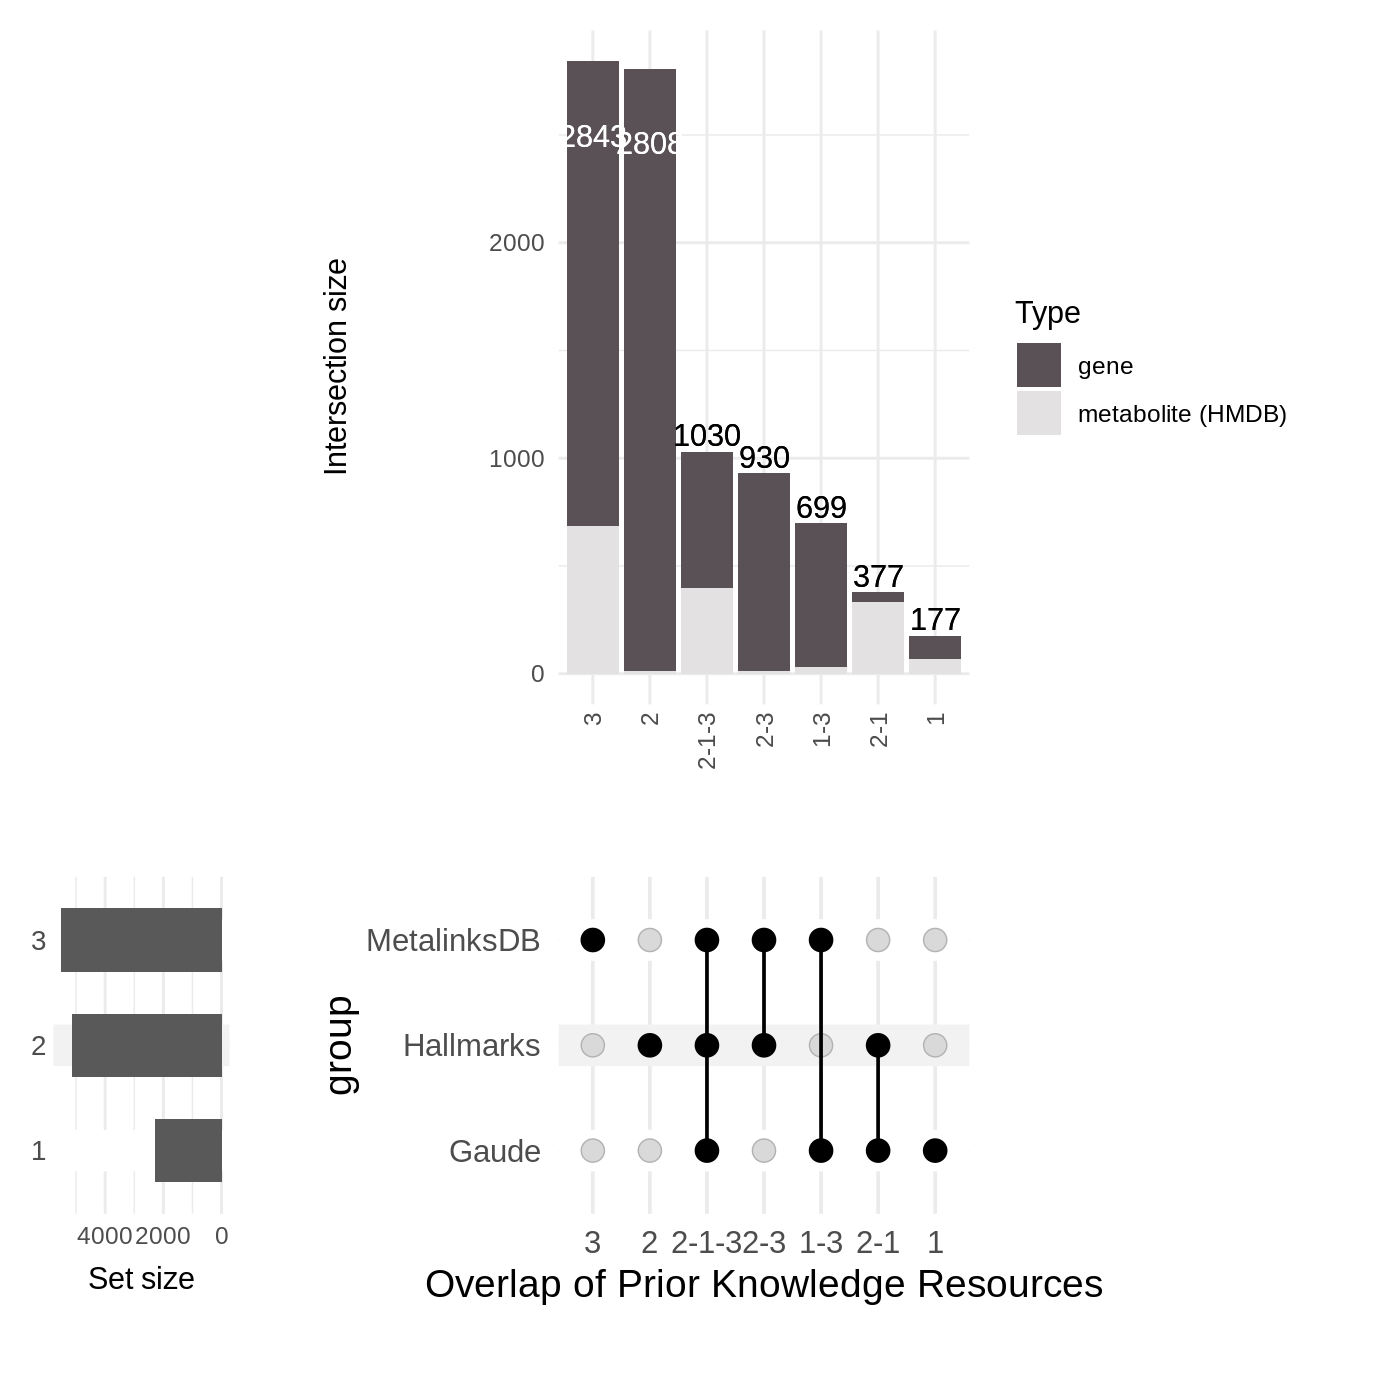

In [ ]:
options(repr.plot.res = 200)

# Convert gene names to metabolite names
Hallmarks_GeneMetab <- MetaProViz::make_gene_metab_set(input_pk=hallmarks,
                                                       metadata_info=c(Target="gene"),
                                                       pk_name="Hallmarks")

Gaude_GeneMetab <- MetaProViz::make_gene_metab_set(input_pk=gaude_pathways,
                                                   metadata_info=c(Target="gene"),
                                                   pk_name="Gaude")


# Compare the PK resources
pk_comp_res <- MetaProViz::compare_pk(data = list(Hallmarks = Hallmarks_GeneMetab[["GeneMetabSet"]],
                                                  Gaude = Gaude_GeneMetab[["GeneMetabSet"]],
                                                  MetalinksDB = MetalinksDB))

head(pk_comp_res$summary_table)

# Section 2: Understand the measured feature space

We will use measured features of which trivial metabolite names and metabolite IDs from one or more databases (e.g. KEGG IDs or ChEBI IDs) have been identified. Our aim is to understand the feature space and the assigned metabolite IDs.



## 2.1. Look at the feature example data

We will use two example datasets, both are among the [18 built-in tables](https://github.com/saezlab/MetaProViz/tree/main/data) coming with the `MetaProViz` package. It means, these are readily available once the package is loaded.

1. Identified metabolite feature names and identifiers from human clear cell renal cell carcinoma (ccRCC), measured by [Metabolon](https://www.metabolon.com/). The data was downloaded from https://www.cell.com/cancer-cell/comments/S1535-6108(15)00468-7

In [ ]:
head(tissue_meta)

Metabolite,SUPER_PATHWAY,SUB_PATHWAY,COMP_ID,PLATFORM,RI,MASS,CAS,PUBCHEM,KEGG,Group_HMDB
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
"1,2-propanediol",Lipid,Ketone bodies,38002,GC/MS,1041.0,117.0,57-55-6;,NA,C00583,HMDB01881
"1,3-dihydroxyacetone",Carbohydrate,"Glycolysis, gluconeogenesis, pyruvate metabolism",35963,GC/MS,1263.0,103.0,62147-49-3;,670,C00184,HMDB01882
"1,5-anhydroglucitol (1,5-AG)",Carbohydrate,"Glycolysis, gluconeogenesis, pyruvate metabolism",20675,GC/MS,1788.7,217.0,154-58-5;,NA,C07326,HMDB02712
10-heptadecenoate (17:1n7),Lipid,Long chain fatty acid,33971,LC/MS Neg,5558.0,267.3,29743-97-3;,5312435,NA,NA
10-nonadecenoate (19:1n9),Lipid,Long chain fatty acid,33972,LC/MS Neg,5775.0,295.4,73033-09-7;,5312513,NA,NA
13-HODE + 9-HODE,Lipid,"Fatty acid, monohydroxy",37752,LC/MS Neg,5247.0,295.2,NA,NA,NA,NA


2. Feature space of the [Biocrates XL kit](https://biocrates.com/mxp-quant-500-xl/), to showcase a good example of documented feature information.

In [ ]:
head(biocrates_features)

TrivialName,TrivialName_Prior2023,Class,CAS,CHEBI,CID,HMDB,INCHI,Key,IUPAC,LIMID,MESH,Molecule,SMILES
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1-Met-His,1-Met-His,Aminoacids Related,332-80-9,50599,92105,HMDB0000001,"InChI=1S/C7H11N3O2/c1-10-3-5(9-4-10)2-6(8)7(11)12/h3-4,6H,2,8H2,1H3,(H,11,12)/t6-/m0/s1",BRMWTNUJHUMWMS-LURJTMIESA-N,(2S)-2-amino-3-(1-methyl-1H-imidazol-4-yl)propanoic acid,NA,NA,1-Methylhistidine,CN1C=NC(C[C@H](N)C(O)=O)=C1
3-IAA,3-IAA,Indoles Derivatives,87-51-4,16411,802,HMDB0000197,"InChI=1S/C10H9NO2/c12-10(13)5-7-6-11-9-4-2-1-3-8(7)9/h1-4,6,11H,5H2,(H,12,13)",SEOVTRFCIGRIMH-UHFFFAOYSA-N,2-(1H-indol-3-yl)acetic acid,NA,NA,Indoleacetic acid,OC(=O)CC1=CNC2=C1C=CC=C2
3-IPA,3-IPA,Indoles Derivatives,830-96-6,43580,3744,HMDB0002302,"InChI=1S/C11H11NO2/c13-11(14)6-5-8-7-12-10-4-2-1-3-9(8)10/h1-4,7,12H,5-6H2,(H,13,14)",GOLXRNDWAUTYKT-UHFFFAOYSA-N,3-(1H-indol-3-yl)propanoic acid,NA,NA,Indole-3-propionic acid,OC(=O)CCC1=CNC2=CC=CC=C12
3-Met-His,3-Met-His,Aminoacids Related,368-16-1,27596,64969,HMDB0000479,"InChI=1S/C7H11N3O2/c1-10-4-9-3-5(10)2-6(8)7(11)12/h3-4,6H,2,8H2,1H3,(H,11,12)/t6-/m0/s1",JDHILDINMRGULE-LURJTMIESA-N,(2S)-2-amino-3-(1-methyl-1H-imidazol-5-yl)propanoic acid,NA,NA,3-Methylhistidine,CN1C=NC=C1C[C@H](N)C(O)=O
5-AVA,5-AVA,Aminoacids Related,660-88-8,15887,138,HMDB0003355,"InChI=1S/C5H11NO2/c6-4-2-1-3-5(7)8/h1-4,6H2,(H,7,8)",JJMDCOVWQOJGCB-UHFFFAOYSA-N,5-aminopentanoic acid,LMFA01100040,NA,5-Aminopentanoic acid,NCCCCC(O)=O
AABA,AABA,Aminoacids Related,"1492-24-6, 2623-91-8, 2835-81-6","28797, 35619, 35621","6657, 80283, 439691","HMDB0000452, HMDB0000650","InChI=1S/C4H9NO2/c1-2-3(5)4(6)7/h3H,2,5H2,1H3,(H,6,7), InChI=1S/C4H9NO2/c1-2-3(5)4(6)7/h3H,2,5H2,1H3,(H,6,7)/t3-/m0/s1, InChI=1S/C4H9NO2/c1-2-3(5)4(6)7/h3H,2,5H2,1H3,(H,6,7)/t3-/m1/s1","QWCKQJZIFLGMSD-GSVOUGTGSA-N, QWCKQJZIFLGMSD-UHFFFAOYSA-N, QWCKQJZIFLGMSD-VKHMYHEASA-N","(2R)-2-aminobutanoic acid, (2S)-2-aminobutanoic acid, 2-aminobutanoic acid","LMFA01100034, LMFA01100043",NA,"D-alpha-Aminobutyric acid, L-alpha-Aminobutyric acid, alpha-aminobutyric acid","CCC(N)C(O)=O, CC[C@@H](N)C(O)=O, CC[C@H](N)C(O)=O"


## 2.2. Which ID types are available for the features?

Classical examples are [HMDB](https://hmdb.ca/), [KEGG](https://www.kegg.jp/), [ChEBI](https://www.ebi.ac.uk/chebi/), [LIPID MAPS](https://www.lipidmaps.org/) or [PubChem](https://pubchem.ncbi.nlm.nih.gov/). Depending on the identifiers available, we know which prior knowledge can be used and whether it's necessary to translate IDs to another metabolite ID type (e.g. PubChem to HMDB).

For the ccRCC data, the authors provided PubChem, KEGG and HMDB IDs. In Biocrates also LIPID MAPS and structural information ([InChI](https://www.inchi-trust.org/)) are available.

## 2.3. How many metabolite IDs per feature are available?

In metabolomics it is common that one measured feature has multiple metabolite IDs. This is due to the difficulties with assigning metabolite IDs to measured data is the uncertainty in the detection of metabolites. Or saying it another way, the database records, hence the identifiers, are typically more specific than the identification of the feature. From mass spec data, constitutional isomers can be distinguished with certain limitations, while conformational isomers and stereoisomers typically not. The limited information, and hence uncertainty, requires us to list all possible IDs when we assign identities to features.

One example is the metabolite Alanine, which can occur in its L- or D- form. If in an experiment those enantiomers have not been distinguished, the correct way would be to either assign two metabolite IDs (L- and D-Alanine) or a more general Alanine ID without chirality information.

Therefore, we should understand how many IDs per feature are available in our data.

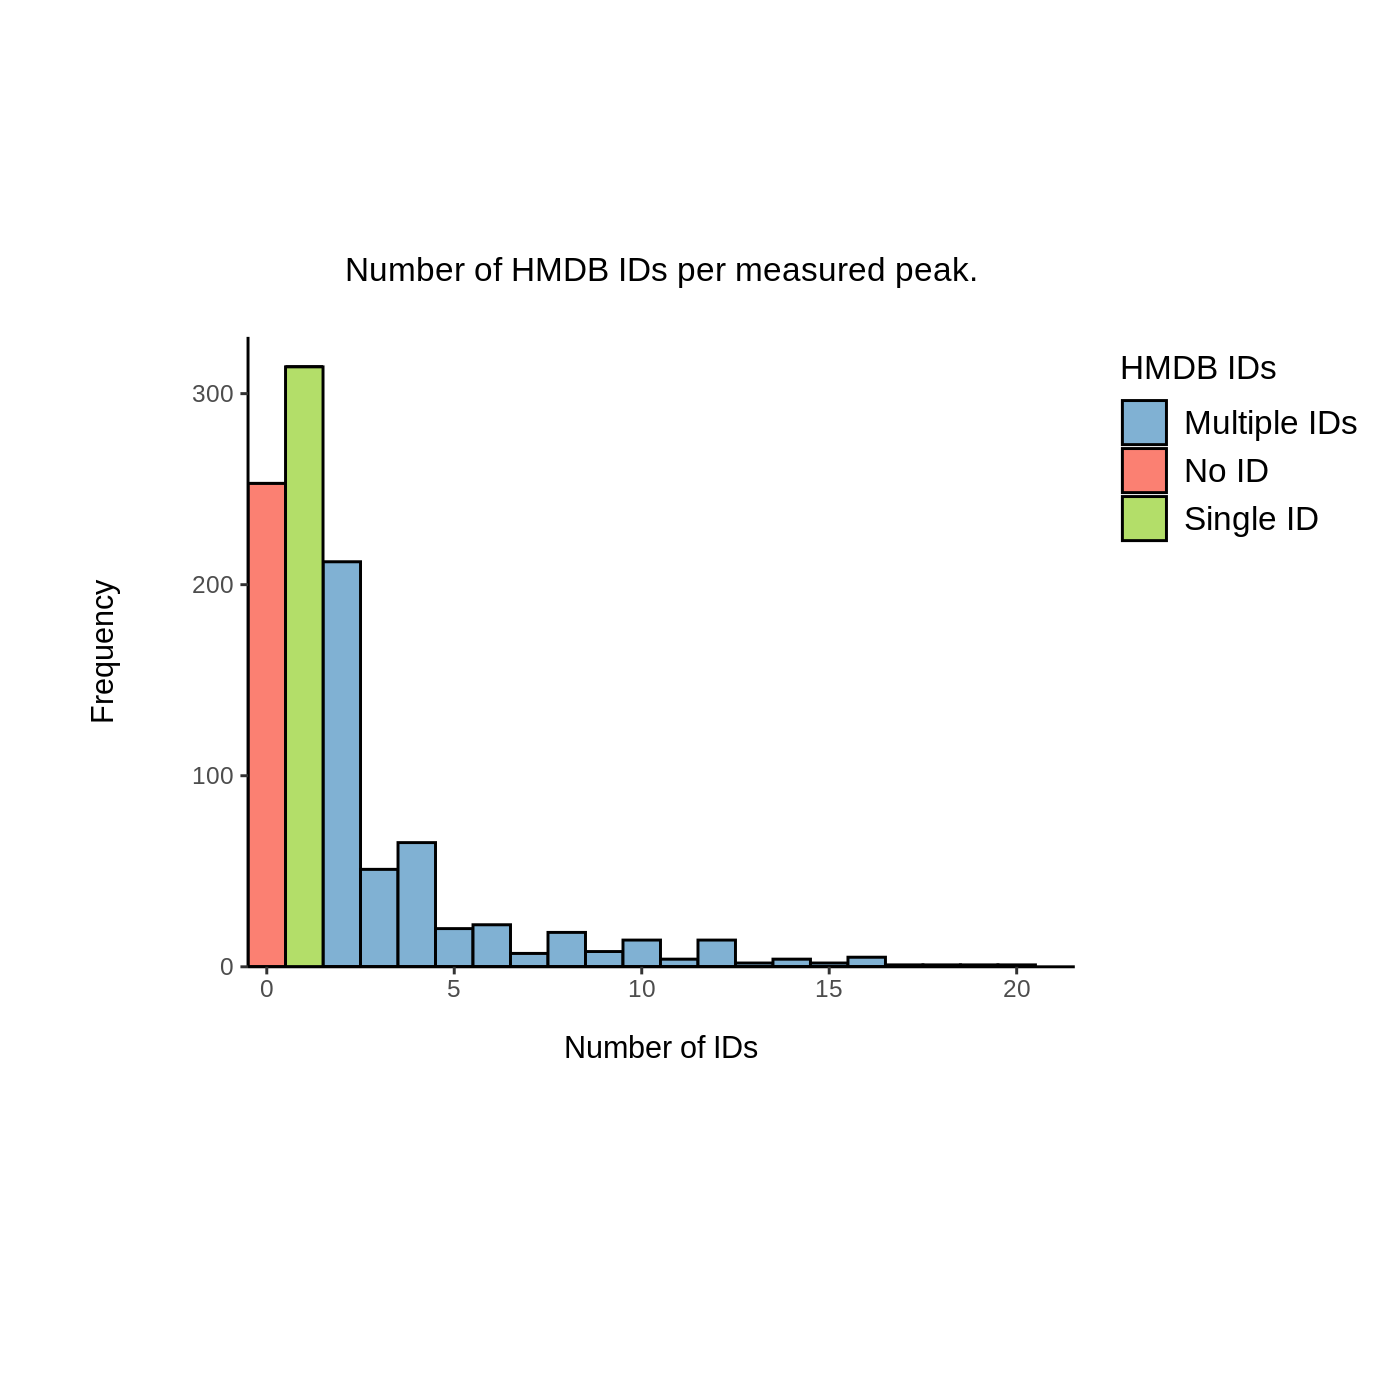

In [ ]:
MetaProViz::count_id(biocrates_features, "HMDB")

- No ID means that there is a detected feature, but no HMDB ID was assigned
- ~300 features have one HMDB ID
- ~400 features have more than one HMDB ID

This points towards rigorous metabolite ID assignment, since we expect multiple IDs for most features due to the  ambiguity explained above.

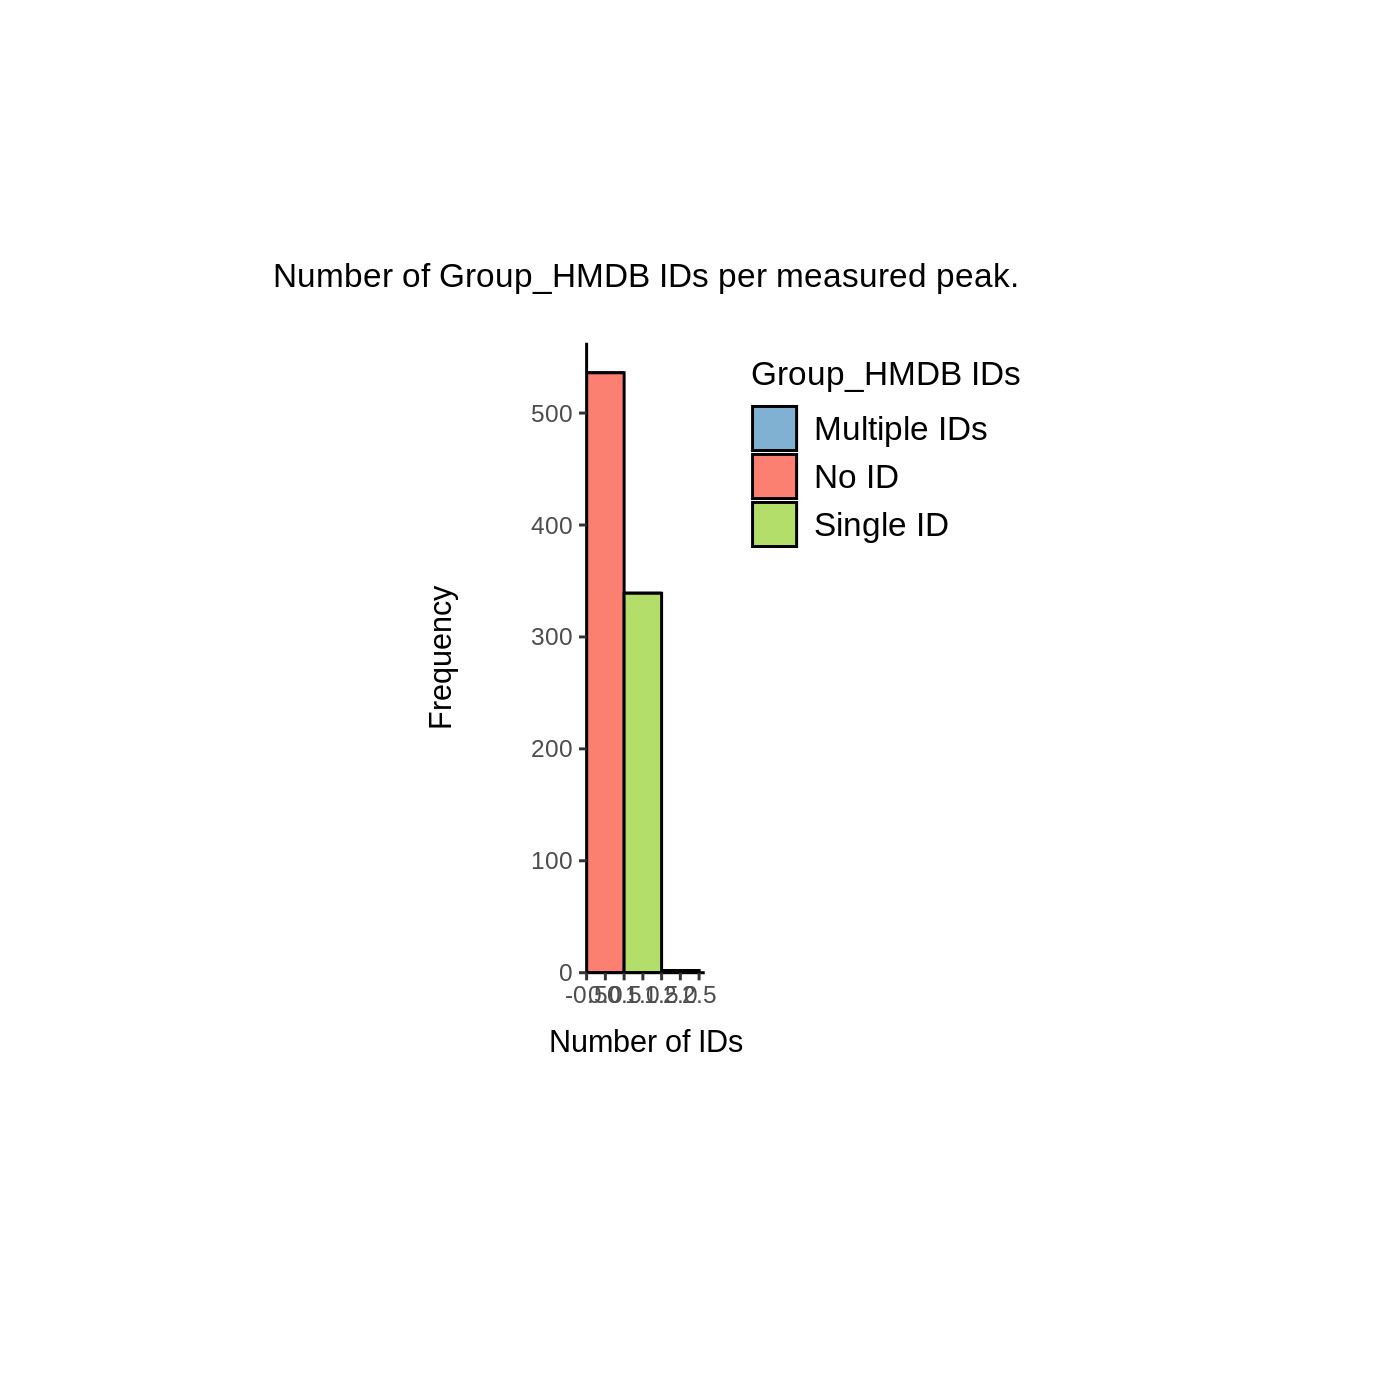

In [ ]:
MetaProViz::count_id(tissue_meta, "Group_HMDB")

- The majority of metabolites have No HMDB ID
- If there is an HMDB ID assigned, we only have one HMDB ID

This points towards possible improvement from our side. At best, we are in contact with the facility that has aquired the measurements and provided the feature identifications. In this case, we can ask questions to understand how the metabolite IDs were assigned and make adaptations based on this. In our example dataset, we will assume the HMDB IDs have been assigned manually and the experimental setup does not account for stereoisomers. This enables us to assign additional potential HMDB IDs per feature.

Warning message in MetaProViz::equivalent_id(data = Input_HMDB, metadata_info = c(InputID = "Group_HMDB"), :
“The following IDs are duplicated and removed: HMDB01859”
chebi is used to find additional potential IDs for hmdb.



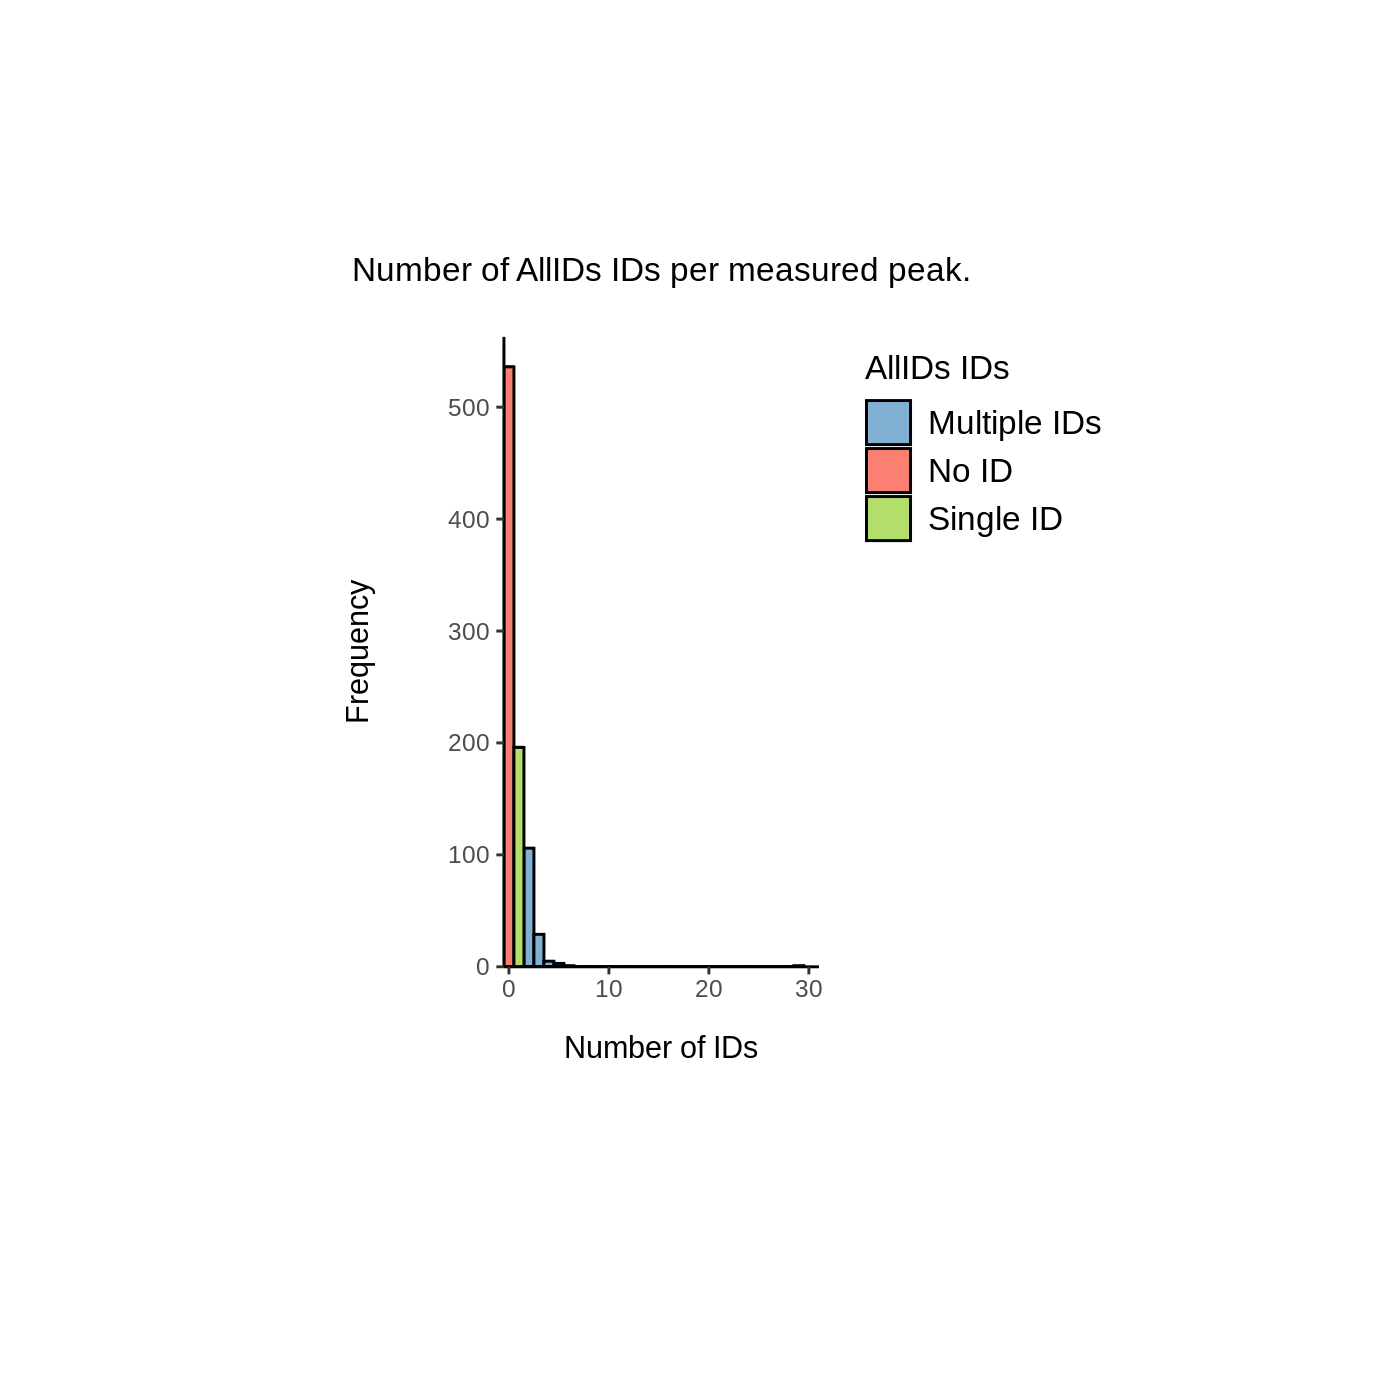

In [ ]:
Input_HMDB <- tissue_meta %>%
  dplyr::filter(!is.na(Group_HMDB)) %>% # ID in the measured data we want to use, hence we remove NA's
  dplyr::select("Metabolite", "Group_HMDB", "SUPER_PATHWAY") # only keep relevant columns

# Add equivalent IDs:
tissue_meta_AddIDs <- MetaProViz::equivalent_id(data= Input_HMDB,
                                                           metadata_info = c(InputID="Group_HMDB"),# ID in the measured data, here we use the HMDB ID
                                                           from = "hmdb")
# Let's see how this has changed the number of entries:
tissue_meta_AddIDs <- merge(x=tissue_meta,
                                       y=tissue_meta_AddIDs,
                                       by="Group_HMDB",
                                       all.x=TRUE)

MetaProViz::count_id(tissue_meta_AddIDs, "AllIDs")

Additionally, some features without HMDB ID could still have an HMDB ID. In this case we can make use of the other ID types available:
1. Check if in case of no HMDB ID there is another ID type available (e.g. KEGG)

In [ ]:
summary_table <-
  tissue_meta |>
  dplyr::filter(is.na(Group_HMDB) & (!is.na(PUBCHEM) | !is.na(KEGG))) |>
  dplyr::summarise(
    Total_Cases = dplyr::n(),
    Not_NA_PUBCHEM = sum(!is.na(PUBCHEM)),
    Not_NA_KEGG = sum(!is.na(KEGG)),
    Both_Not_NA = sum(!is.na(PUBCHEM) & !is.na(KEGG))
  )

summary_table

Total_Cases,Not_NA_PUBCHEM,Not_NA_KEGG,Both_Not_NA
<int>,<int>,<int>,<int>
160,159,25,24


In [ ]:
no_hmdb <- dplyr::filter(tissue_meta, is.na(Group_HMDB) & (!is.na(PUBCHEM) | !is.na(KEGG)))
head(no_hmdb)

Metabolite,SUPER_PATHWAY,SUB_PATHWAY,COMP_ID,PLATFORM,RI,MASS,CAS,PUBCHEM,KEGG,Group_HMDB
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
10-heptadecenoate (17:1n7),Lipid,Long chain fatty acid,33971,LC/MS Neg,5558,267.3,29743-97-3;,5312435,NA,NA
10-nonadecenoate (19:1n9),Lipid,Long chain fatty acid,33972,LC/MS Neg,5775,295.4,73033-09-7;,5312513,NA,NA
16-hydroxypalmitate,Lipid,"Fatty acid, monohydroxy",39609,LC/MS Neg,5232,271.3,506-13-8;,10466,C18218,NA
1-arachidonoylglycerophosphocholine*,Lipid,Lysolipid,33228,LC/MS Pos,5554,544.3,NA,NA,C05208,NA
1-linoleoylglycerol (1-monolinolein),Lipid,Monoacylglycerol,27447,GC/MS,2181,395.3,2277-28-3;,5283469,NA,NA
1-linoleoylglycerophosphocholine,Lipid,Lysolipid,34419,LC/MS Pos,5574,520.4,NA,11988421,C04100,NA


Above, for example, 16-hydroxypalmitate certainly has an HMDB ID, it's still missing from the table. We can see the structures associated to [PubChem:10466](https://pubchem.ncbi.nlm.nih.gov/compound/10466) and [KEGG:C18218](https://www.genome.jp/entry/C18218) are indeed identical, and as we expect, the same structure is in HMDB too, under the ID [HMDB0006294](https://hmdb.ca/metabolites/HMDB0006294).

Since we have PubChem or KEGG IDs for features without HMDB IDs, we can:

2. **Translate** from available IDs (e.g. KEGG) to HMDB

The `MetaProViz::translate_id` uses [`OmnipathR::translate_ids`](https://r.omnipathdb.org/reference/translate_ids.html) and sources the translation data from [RaMP-DB](https://rampdb.nih.gov/) (Braisted et al. 2023).

In [ ]:
tissue_meta_translated <-
  MetaProViz::translate_id(no_hmdb, metadata_info = list(InputID = "PUBCHEM", grouping_variable = "SUPER_PATHWAY"), from = "pubchem", to = "hmdb") |>
  extract2("TranslatedDF") |>
  rename(hmdb_from_pubchem = hmdb) |>
  MetaProViz::translate_id(metadata_info = list(InputID = "KEGG", grouping_variable = "SUPER_PATHWAY"), from = "kegg", to = "hmdb") |>
  extract2("TranslatedDF") |>
  rename(hmdb_from_kegg = hmdb)

head(tissue_meta_translated)

Warning message in MetaProViz::translate_id(no_hmdb, metadata_info = list(InputID = "PUBCHEM", :
“The following IDs are duplicated within one group: 5.24601e+13, 6.99312e+13”


Metabolite,SUPER_PATHWAY,SUB_PATHWAY,COMP_ID,PLATFORM,RI,MASS,CAS,PUBCHEM,KEGG,Group_HMDB,hmdb_from_pubchem,hmdb_from_kegg
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
10-heptadecenoate (17:1n7),Lipid,Long chain fatty acid,33971,LC/MS Neg,5558,267.3,29743-97-3;,5312435,NA,NA,"HMDB0060038, HMDB0062542",
10-nonadecenoate (19:1n9),Lipid,Long chain fatty acid,33972,LC/MS Neg,5775,295.4,73033-09-7;,5312513,NA,NA,"HMDB0013622, HMDB0062543, HMDB0062658",
16-hydroxypalmitate,Lipid,"Fatty acid, monohydroxy",39609,LC/MS Neg,5232,271.3,506-13-8;,10466,C18218,NA,"HMDB0006294, HMDB0155887","HMDB0006294, HMDB0155887"
1-arachidonoylglycerophosphocholine*,Lipid,Lysolipid,33228,LC/MS Pos,5554,544.3,NA,NA,C05208,NA,,
1-linoleoylglycerol (1-monolinolein),Lipid,Monoacylglycerol,27447,GC/MS,2181,395.3,2277-28-3;,5283469,NA,NA,HMDB0242115,
1-linoleoylglycerophosphocholine,Lipid,Lysolipid,34419,LC/MS Pos,5574,520.4,NA,11988421,C04100,NA,,


For our previous example, 16-hydroxypalmitate, we got two HMDB IDs. What might be the explanation?

In [ ]:
head(tissue_meta_AddIDs)

,Group_HMDB,Metabolite.x,SUPER_PATHWAY.x,SUB_PATHWAY,COMP_ID,PLATFORM,RI,MASS,CAS,PUBCHEM,KEGG,Metabolite.y,SUPER_PATHWAY.y,PotentialAdditionalIDs,AllIDs
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,192,hydrochlorothiazide,Xenobiotics,Drug,39625,LC/MS Neg,2041.6,296.1,58-93-5;,3639,340,hydrochlorothiazide,Xenobiotics,NA,192
2,HMDB00008,2-hydroxybutyrate (AHB),Amino acid,"Cysteine, methionine, SAM, taurine metabolism",21044,GC/MS,1169.4,130.9,3347-90-8;,440864,C05984,2-hydroxybutyrate (AHB),Amino acid,HMDB0000008,HMDB0000008
3,HMDB00017,pyridoxate,Cofactors and vitamins,Vitamin B6 metabolism,31555,LC/MS Neg,2210.0,182.1,82-82-6 ;,6723,C00847,pyridoxate,Cofactors and vitamins,HMDB0000017,HMDB0000017
4,HMDB00020,4-hydroxyphenylacetate,Amino acid,Phenylalanine & tyrosine metabolism,541,GC/MS,1630.6,179.0,156-38-7;,4693933,C00642,4-hydroxyphenylacetate,Amino acid,HMDB0000020,HMDB0000020
5,HMDB00026,3-ureidopropionate,Amino acid,Alanine and aspartate metabolism,3155,LC/MS Pos,1062.0,133.1,462-88-4;,111,C02642,3-ureidopropionate,Amino acid,"HMDB0000026, HMDB0062812","HMDB0000026,HMDB0062812"
6,HMDB00034,adenine,Nucleotide,"Purine metabolism, adenine containing",554,GC/MS,1804.2,264.0,73-24-5;,190,C00147,adenine,Nucleotide,HMDB0000034,HMDB0000034


In [ ]:
# here we combine the tables above, created by equivalent_id and translate_id:
tissue_meta_translated <-
  left_join(
    tissue_meta_AddIDs |>
      select(Metabolite = Metabolite.x, SUPER_PATHWAY = SUPER_PATHWAY.x, COMP_ID, KEGG, PUBCHEM, Group_HMDB, hmdb_from_equivalentid = AllIDs),
    tissue_meta_translated |>
      select(COMP_ID, hmdb_from_pubchem, hmdb_from_kegg) |> mutate(across(starts_with("hmdb_from"), ~na_if(., ""))),
    by = 'COMP_ID'
  ) |>
  rowwise() |>
  mutate(hmdb_combined = list(unique(na.omit(unlist(str_split(across(starts_with("hmdb_from")), ",")))))) |>
  mutate(hmdb_combined = paste0(hmdb_combined, collapse = ',')) |>  # we concatenate by "," only for the sake of printing in notebook
  ungroup()

head(tissue_meta_translated)

Metabolite,SUPER_PATHWAY,COMP_ID,KEGG,PUBCHEM,Group_HMDB,hmdb_from_equivalentid,hmdb_from_pubchem,hmdb_from_kegg,hmdb_combined
<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
hydrochlorothiazide,Xenobiotics,39625,340,3639,192,192,NA,NA,192
2-hydroxybutyrate (AHB),Amino acid,21044,C05984,440864,HMDB00008,HMDB0000008,NA,NA,HMDB0000008
pyridoxate,Cofactors and vitamins,31555,C00847,6723,HMDB00017,HMDB0000017,NA,NA,HMDB0000017
4-hydroxyphenylacetate,Amino acid,541,C00642,4693933,HMDB00020,HMDB0000020,NA,NA,HMDB0000020
3-ureidopropionate,Amino acid,3155,C02642,111,HMDB00026,"HMDB0000026,HMDB0062812",NA,NA,"HMDB0000026,HMDB0062812"
adenine,Nucleotide,554,C00147,190,HMDB00034,HMDB0000034,NA,NA,HMDB0000034


> *Note: below, three plots appear after each other, and some might be **hidden,** you need to **scroll** within the cell to see them.*


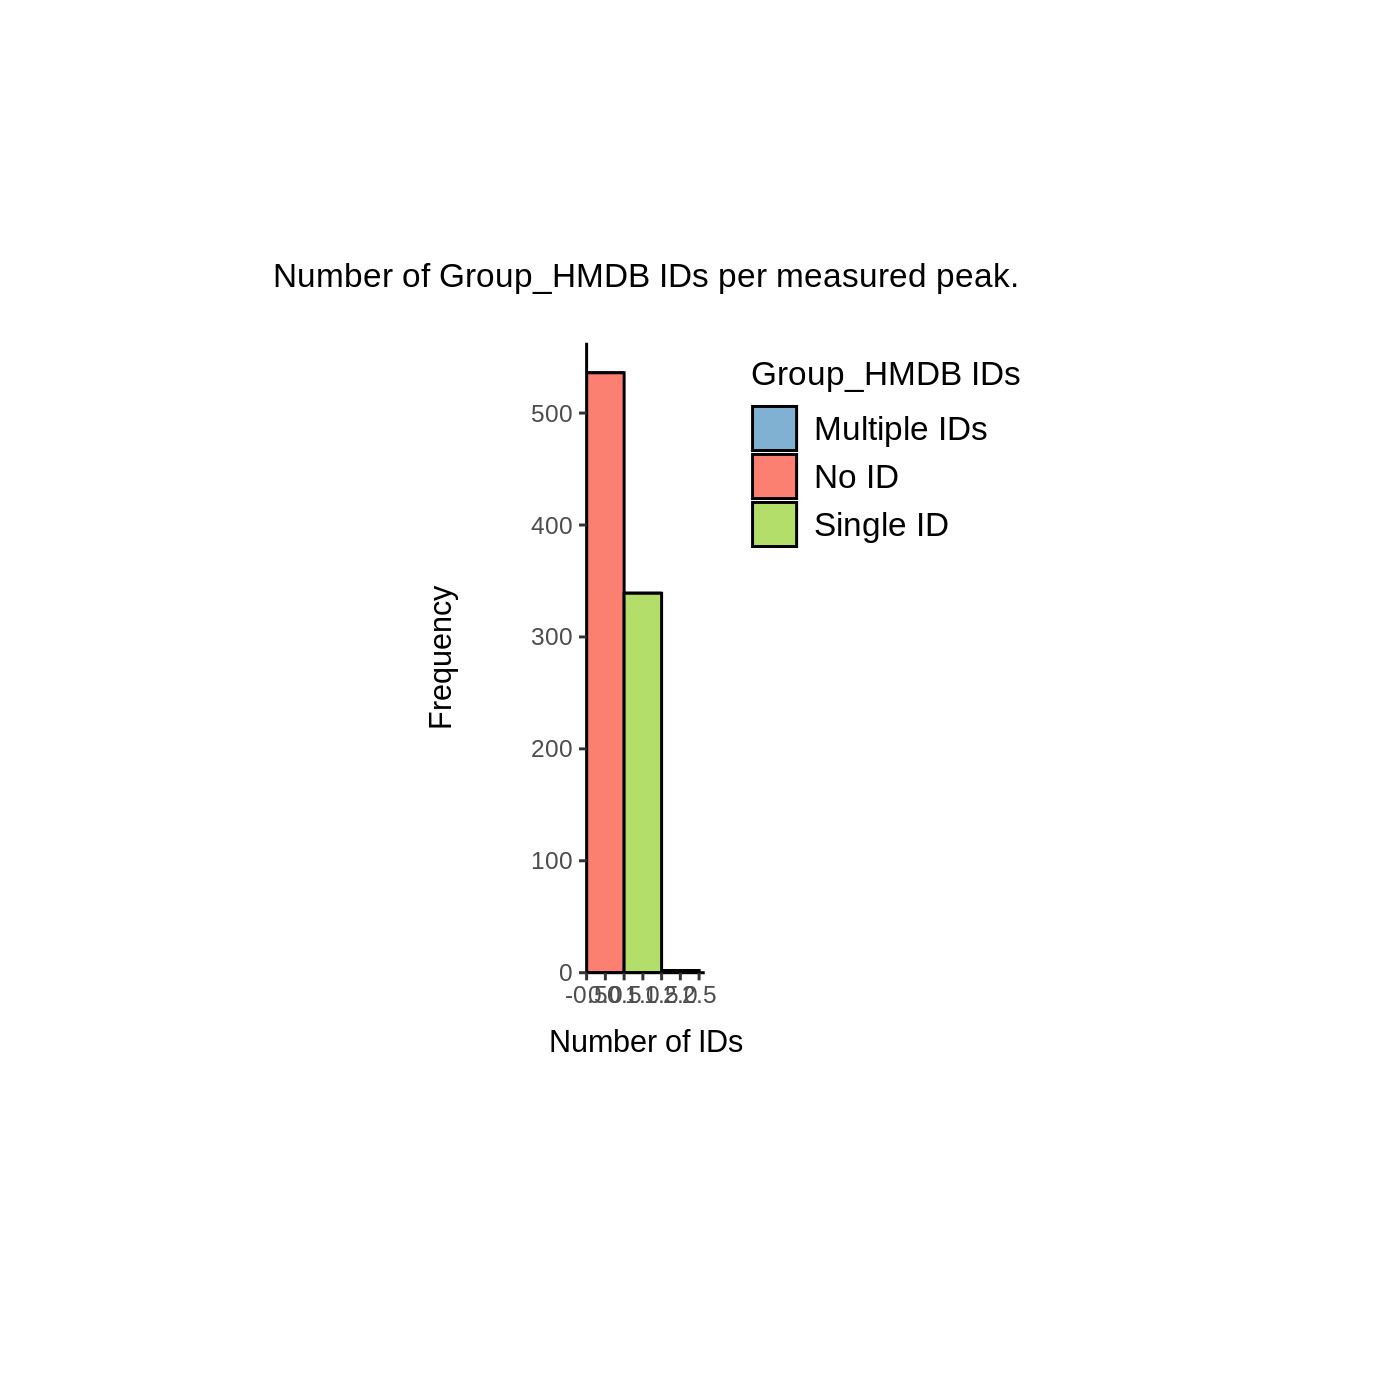

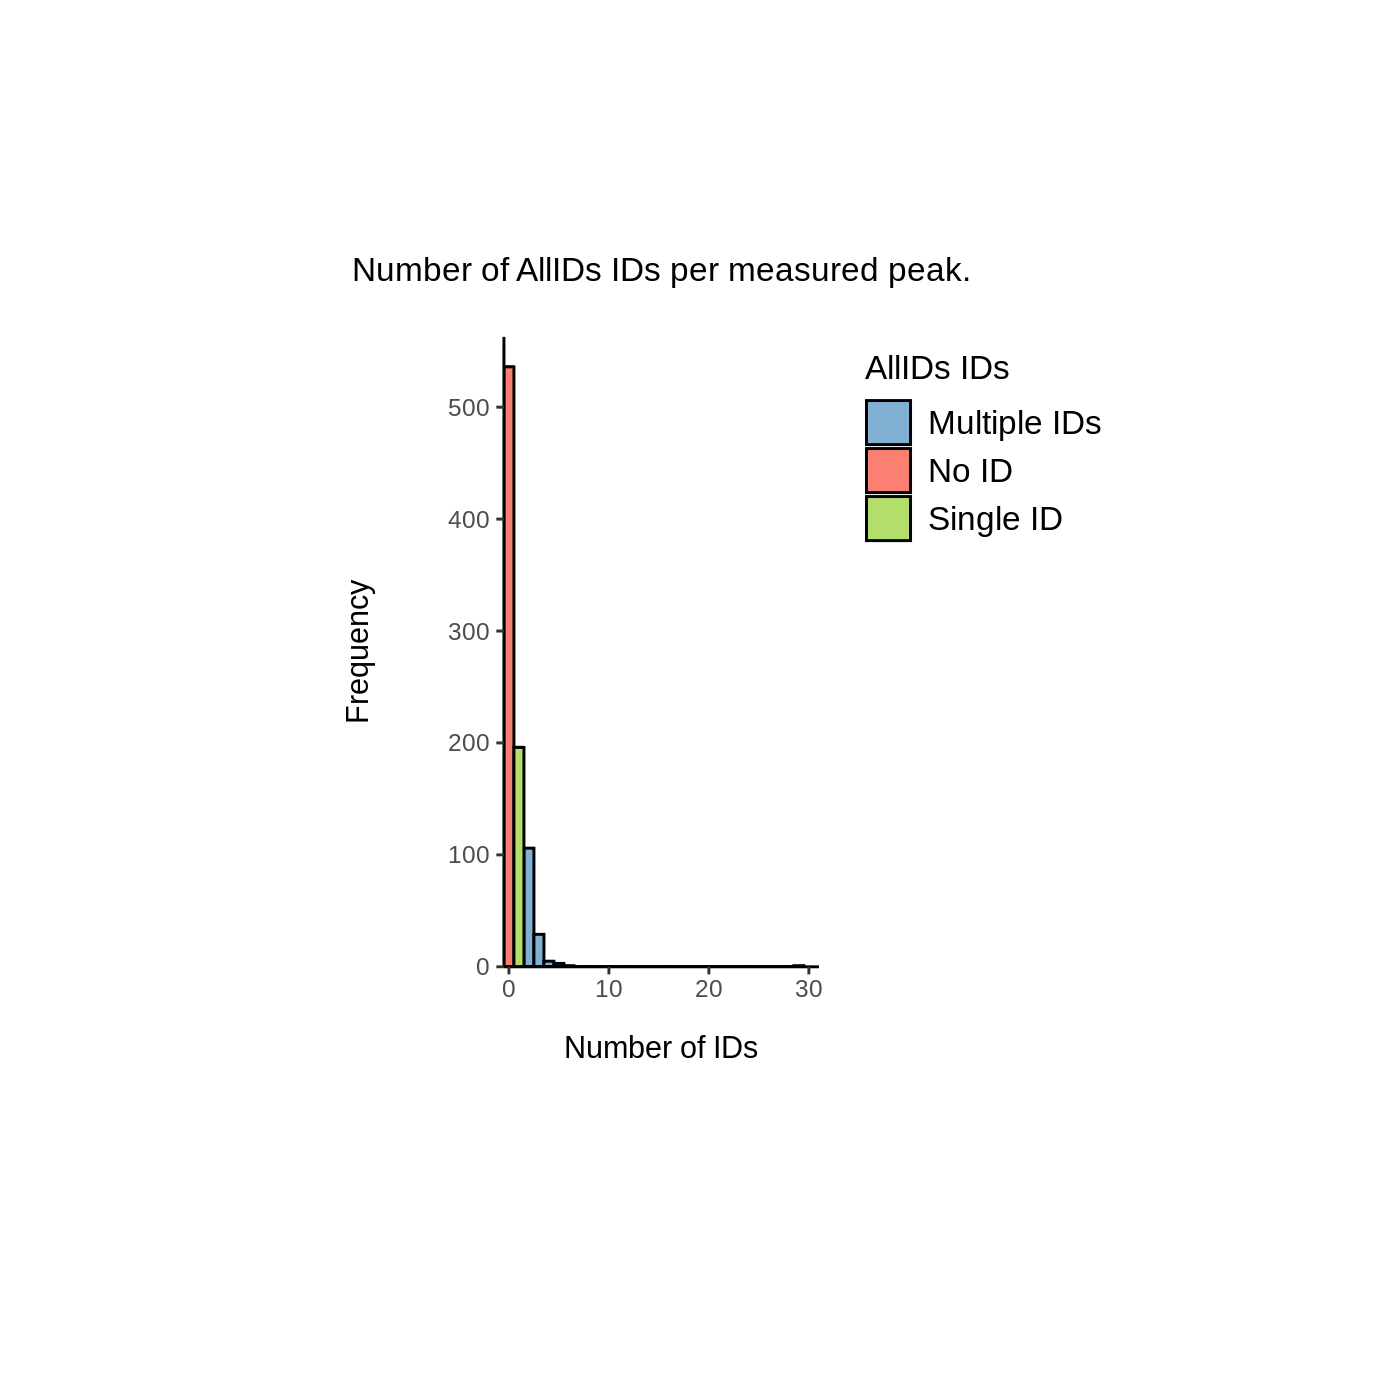

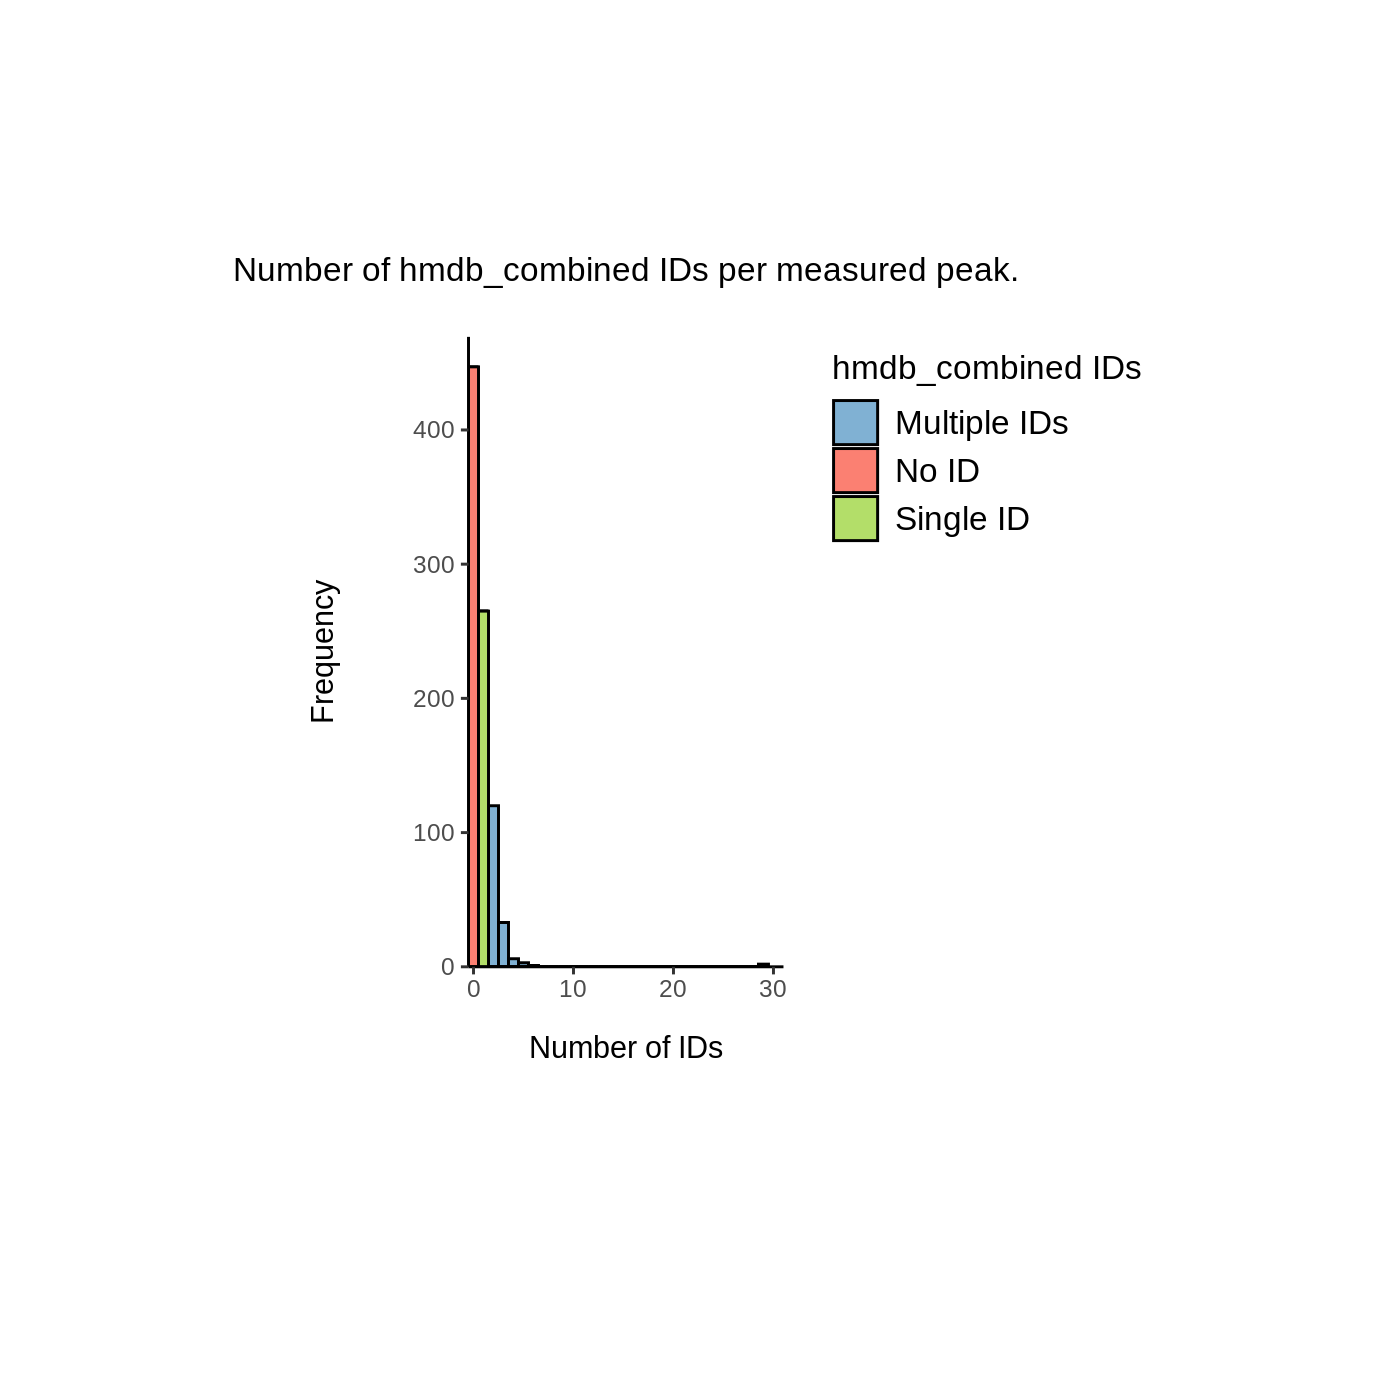

In [ ]:
MetaProViz::count_id(tissue_meta, "Group_HMDB")
MetaProViz::count_id(tissue_meta_AddIDs, "AllIDs")
MetaProViz::count_id(tissue_meta_translated, "hmdb_combined")

## 2.4. ID translation in OmnipathR

OmnipathR uses data from 9 different resources for ID translation, and translates not only metabolite, but gene and protein identifiers too. The translation resources are the following:

In [ ]:
id_translation_resources()

[1] "uniprot"      "uploadlists"  "uniprot_from" "uniprot_to"   "ensembl"     
[6] "oma"          "hmdb"         "chalmers_gem" "ramp"

The supported ID types for each resource, are listed here. OmnipathR as an alternative, supports simpler synonyms (`in_omnipath` column):

In [ ]:
id_types()

in_resource,in_omnipath,resource,entity_type
<chr>,<chr>,<chr>,<chr>
xref_geneid,entrez,uniprot,protein
gene_primary,genesymbol,uniprot,protein
gene_synonym,genesymbol_syn,uniprot,protein
xref_hgnc,hgnc,uniprot,protein
xref_embl,embl,uniprot,protein
xref_refseq,refseqp,uniprot,protein
xref_ensembl,enst,uniprot,protein
id,uniprot_entry,uniprot,protein
accession,uniprot,uniprot,protein


The [`OmnipathR::translate_ids`](https://r.omnipathdb.org/reference/translate_ids.html) function translates one column to one or more other ID types, using the selected translation resource. Here we only show a minimal example, translation the HMDB IDs from the gender dementia study to other common ID types, using RaMP as a translation backend (`ramp = TRUE`). Note: in the training **do not** select the `hmdb` backend (`hmdb = TRUE`), because it triggers an enormous download. If you do, stop the execution of the notebook cell.

In [ ]:
translate_ids(gender_top_features_hmdb, hmdb, pubchem, kegg, ramp = TRUE)

hmdb,rampId,Synonym,commonName,gender_pval,pubchem,kegg
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
HMDB0000064,RAMP_C_000218700,creatine,Creatine,1.70e-08,586,C00300
HMDB0000791,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11,11953814,C02838
HMDB0000834,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11,11953814,C02838
HMDB00064,RAMP_C_000218700,creatine,Creatine,1.70e-08,586,C00300
HMDB0012881,RAMP_C_000008033,n-acetylcarnosine,Acetylcarnosine,6.47e-13,10221026,NA
HMDB00791,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11,11953814,C02838
HMDB00834,RAMP_C_000000619,octanoylcarnitine,Octanoylcarnitine,1.22e-11,11953814,C02838
HMDB0255058,RAMP_C_000168839,n-acetylcarnosine,N-Acetylcarnosine,6.47e-13,91814,NA
HMDB12881,RAMP_C_000008033,n-acetylcarnosine,Acetylcarnosine,6.47e-13,10221026,NA


## 2.5. What is the metabolite ID coverage?

It's important to understand how many features are excluded when using one one specific metabolite ID type in the prior knowledge.


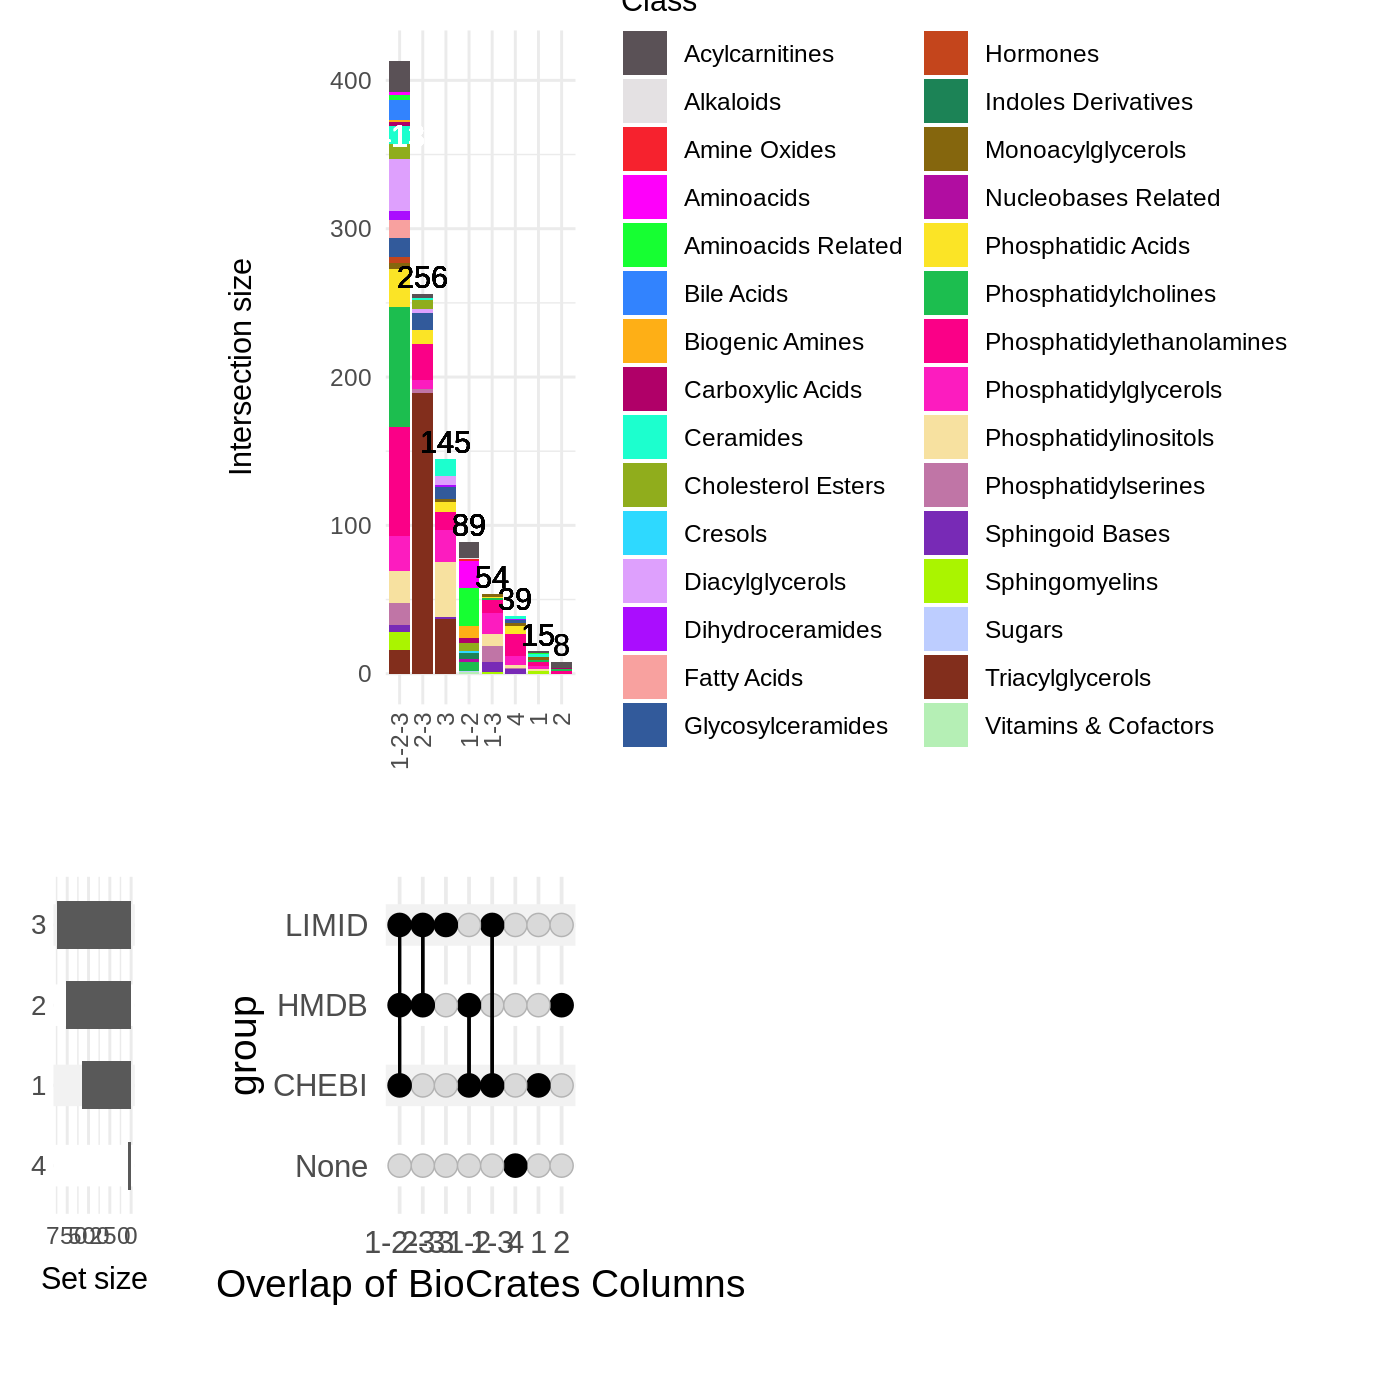

In [ ]:
Biocrates_CompareIDs <- MetaProViz::compare_pk(data = list(Biocft = biocrates_features),
                                               metadata_info = list(Biocft = c("CHEBI", "HMDB", "LIMID")),
                                               plot_name = "Overlap of BioCrates Columns")



The Upset plot shows:
- Less than half the metabolites has CHEBI+HMDB+LIMID (n=440)
- If you relied only on CHEBI, then you would miss at least 229 metabolites with HMDB+LIMID
- If you relied only on HMDB, then you would miss at least 126 metabolites with CHEBI+LIMID
- If you relied only on LIMID, then you would miss at least 89 metabolites with CHEBI+HMDB + 22 with only CHEBI + 8 with only HMDB and 32 with no LIMID/CHEBI/HMDB identifiers

Important note:
- Keep in mind that there is not a direct 1:1 relationship between the number of Biocrates metabolites with, e.g. a ChEBI ID, and the number of unique ChEBI IDs that they map to. This upset plot is treating each Biocrates feature as an individual entry and categorising whether it has a ChEBI, HMDB, LIMID ID, etc. However we are not considering what those ChEBI, HMDB, LIMIDs actually are. So it is possible that there are cases where the number of metabolites is higher, or lower, than the number of unique IDs due to multimapping.

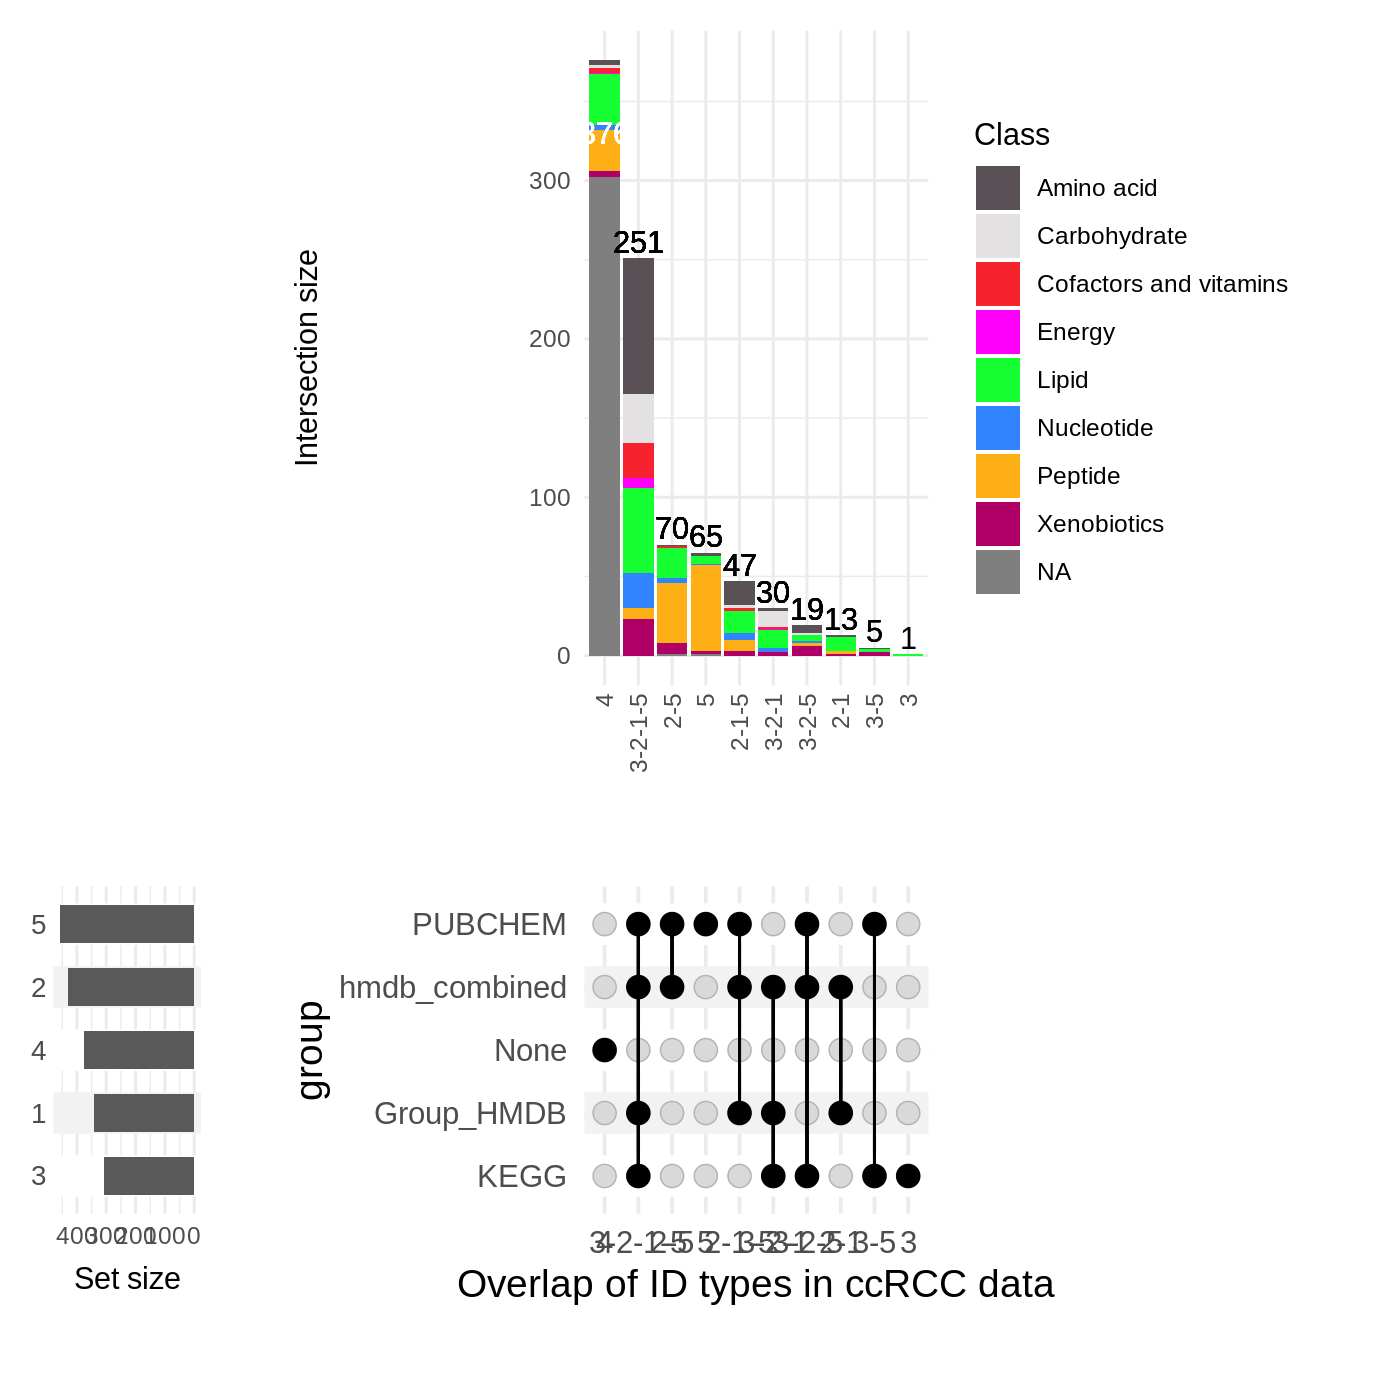

In [ ]:
ccRCC_CompareIDs <- MetaProViz::compare_pk(data = list(Biocft = tissue_meta_translated |> dplyr::rename("Class"="SUPER_PATHWAY")),
                                           name_col = "Metabolite",
                                           metadata_info = list(Biocft = c("KEGG", "hmdb_combined", "Group_HMDB", "PUBCHEM")),
                                           plot_name = "Overlap of ID types in ccRCC data")

# Section 3: Enrichment analysis

## 3.1. Load example data:

This is differential analysis results of human clear cell renal cell carcinoma (ccRCC). The data was downloaded from https://www.cell.com/cancer-cell/comments/S1535-6108(15)00468-7 and then we performed differential analysis.
If you want to understand how those where generated you can follow the MetaProViz vignette: https://saezlab.github.io/MetaProViz/articles/sample-metadata.html


In [ ]:
#Load data
tumour_vs_normal <- readr::read_csv('data-ebi-metabo/DMA_TUMOR_vs_NORMAL_2025-05-21.csv', col_types = cols())

head(tumour_vs_normal)

Metabolite,Log2FC,AveExpr,t.val,p.val,p.adj,B,log2(DIAG-16076),log2(DIAG-16077),log2(DIAG-16078),⋯,log2(DIAG-16346),log2(DIAG-16347),log2(DIAG-16348),log2(DIAG-16349),log2(DIAG-16350),log2(DIAG-16351),log2(DIAG-16352),log2(DIAG-16353),log2(DIAG-16354),log2(DIAG-16355)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"1,2-propanediol",-0.1632915,-0.003354718,-1.6137010,1.077343e-01,1.326319e-01,-6.598891,-0.4922409,-1.55898404,-1.2744386,⋯,0.2130125,-0.2448116,0.79893474,1.32781094,0.00367419,0.8108190,-0.5473856,0.04670478,-0.459308093,0.2408174
1-arachidonoylglycerophosphoethanolamine*,-1.2572985,-0.020413813,-15.3954757,4.875697e-39,6.041625e-38,77.812680,-0.4046166,0.06157161,-0.7033464,⋯,-0.9305618,0.7517328,0.22699921,0.16459708,0.09912281,0.2343284,-0.1190136,1.45481759,-0.488455046,-0.4890259
4-hydroxyphenylacetate,-1.4687752,-0.850921163,-15.3356063,8.022664e-39,9.526913e-38,77.316193,-1.8093320,0.53218129,-1.8093320,⋯,-0.5054533,-1.1383400,0.21953718,0.03835611,-1.80933205,-0.2807833,-1.8093320,-0.37306191,-1.809332047,-1.8093320
4-methyl-2-oxopentanoate,-0.1162268,-0.736524586,-0.7688395,4.426456e-01,4.918284e-01,-7.601822,-1.4405963,-2.03276645,1.3844140,⋯,-0.2127280,0.9009267,0.46102767,-0.22038391,0.80817661,-2.0327665,0.7322527,-2.03276645,0.379350362,0.4075823
"5,6-dihydrouracil",1.9035446,-0.745763730,8.6234736,5.161637e-16,2.029057e-15,25.096211,-0.2120243,-2.51271124,-2.8192411,⋯,1.8315785,-1.2887483,-0.65402462,-0.62784801,0.10649975,-1.4718368,0.0000000,-4.17540320,0.007600261,0.1759001
5-aminovalerate,0.8738976,-0.819336733,7.0551851,1.389851e-11,3.998343e-11,15.033923,-1.7695313,-0.46388143,-0.6946878,⋯,0.0000000,-1.7695313,0.03253676,-0.76912315,-1.76953135,-1.7695313,-0.4462129,-1.76953135,-1.769531349,-1.7695313


Merge with the extended HMDB IDs and the other relevant feature information:

In [ ]:
tumour_vs_normal <- merge(
  x = tumour_vs_normal |> select(1:6),
  y = tissue_meta_translated,
  by.x = "Metabolite"
)

head(tumour_vs_normal)

,Metabolite,Log2FC,AveExpr,t.val,p.val,p.adj,SUPER_PATHWAY,COMP_ID,KEGG,PUBCHEM,Group_HMDB,hmdb_from_equivalentid,hmdb_from_pubchem,hmdb_from_kegg,hmdb_combined
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1-arachidonoylglycerophosphocholine*,-0.4332589,0.05159982,-2.642546,8.698152e-03,1.221169e-02,Lipid,33228,C05208,NA,NA,NA,NA,NA,
2,1-arachidonoylglycerophosphoethanolamine*,-1.2572985,-0.02041381,-15.395476,4.875697e-39,6.041625e-38,Lipid,35186,NA,NA,HMDB11517,HMDB0011517,NA,NA,HMDB0011517
3,1-arachidonoylglycerophosphoinositol*,-0.9684910,-0.12664649,-11.496667,2.945428e-25,1.695853e-24,Lipid,34214,NA,NA,NA,NA,NA,NA,
4,1-arachidonylglycerol,-0.2466715,-1.24275890,-2.464893,1.431416e-02,1.942636e-02,Lipid,34397,C13857,5282281,HMDB11572,HMDB11572,NA,NA,HMDB11572
5,1-docosahexaenoylglycerophosphocholine*,-0.9152874,-0.55839208,-6.523272,3.270440e-10,8.435072e-10,Lipid,33822,NA,NA,NA,NA,NA,NA,
6,1-heptadecanoylglycerophosphocholine,-1.6187167,-0.35312006,-9.861885,7.510589e-20,3.480517e-19,Lipid,33957,NA,NA,HMDB12108,"HMDB0010380,HMDB0010381,HMDB0010382,HMDB0010383,HMDB0010384,HMDB0010385,HMDB0010387,HMDB0010390,HMDB0010391,HMDB0010392,HMDB0010393,HMDB0010395,HMDB0010396,HMDB0010397,HMDB0010398,HMDB0010399,HMDB0010400,HMDB0010401,HMDB0010402,HMDB0010403,HMDB0010404,HMDB0010405,HMDB0010406,HMDB0010408,HMDB0012108,HMDB0013122,HMDB0062541,HMDB0094688,HMDB0258493",NA,NA,"HMDB0010380,HMDB0010381,HMDB0010382,HMDB0010383,HMDB0010384,HMDB0010385,HMDB0010387,HMDB0010390,HMDB0010391,HMDB0010392,HMDB0010393,HMDB0010395,HMDB0010396,HMDB0010397,HMDB0010398,HMDB0010399,HMDB0010400,HMDB0010401,HMDB0010402,HMDB0010403,HMDB0010404,HMDB0010405,HMDB0010406,HMDB0010408,HMDB0012108,HMDB0013122,HMDB0062541,HMDB0094688,HMDB0258493"


## 3.2. Choose the prior knowledge

We discussed above that the choice of prior knowledge depends on the biological question of interest, but will need to have a certain overlap with the data.
So let's check how many metabolites of our data are found in the prior knowledge. Here it is taken into account that a detected feature can have multiple IDs assigned and cases that may inflate/deflate the analysis (e.g. one measured feature has three HMDB IDs, which map to three different entries in the DB).

In [ ]:
ccRCC_to_ChemicalClass <- MetaProViz::checkmatch_pk_to_data(data = tumour_vs_normal,
                                                          input_pk = ChemicalClass,
                                                          metadata_info = c(InputID = "hmdb_combined", PriorID = "class_source_id", grouping_variable = NULL))

head(ccRCC_to_ChemicalClass$data_Matched |> select(1:14) |> filter(!is.na(ActionRequired)))

Warning message in MetaProViz::checkmatch_pk_to_data(data = tumour_vs_normal, input_pk = ChemicalClass, :
“147 duplicated IDs were removed from columnhmdb_combined”
No class_source_id provided. If this was not intentional, please check your input.



,hmdb_combined,found_match_in_PK,matches,match_overlap_percentage,original_count,matches_count,grouping_variable,OriginalEntry_data,num_PK_entries,num_PK_entries_groups,num_Input_entries,num_Input_entries_groups,ActionRequired,Detection
,<chr>,<lgl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,HMDB0000008,TRUE,HMDB0000008,100,1,1,None,HMDB0000008,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
2,HMDB0000017,TRUE,HMDB0000017,100,1,1,None,HMDB0000017,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
3,HMDB0000020,TRUE,HMDB0000020,100,1,1,None,HMDB0000020,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
4,HMDB0000034,TRUE,HMDB0000034,100,1,1,None,HMDB0000034,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
5,HMDB0000045,TRUE,HMDB0000045,100,1,1,None,HMDB0000045,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
6,HMDB0000056,TRUE,HMDB0000056,100,1,1,None,HMDB0000056,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group


In [ ]:
ccRCC_to_MetalinksDB <- MetaProViz::checkmatch_pk_to_data(data = tumour_vs_normal,
                                                          input_pk = MetalinksDB,
                                                          metadata_info = c(InputID = "hmdb_combined", PriorID = "hmdb", grouping_variable = NULL))

head(ccRCC_to_MetalinksDB$data_Matched |> select(1:14) |> filter(!is.na(ActionRequired)))

Warning message in MetaProViz::checkmatch_pk_to_data(data = tumour_vs_normal, input_pk = MetalinksDB, :
“147 duplicated IDs were removed from columnhmdb_combined”
No hmdb provided. If this was not intentional, please check your input.

Warning message in MetaProViz::checkmatch_pk_to_data(data = tumour_vs_normal, input_pk = MetalinksDB, :
“40766 duplicated IDs were removed from columnhmdb”


,hmdb_combined,found_match_in_PK,matches,match_overlap_percentage,original_count,matches_count,grouping_variable,OriginalEntry_data,num_PK_entries,num_PK_entries_groups,num_Input_entries,num_Input_entries_groups,ActionRequired,Detection
,<chr>,<lgl>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,HMDB0000008,TRUE,HMDB0000008,100,1,1,None,HMDB0000008,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
2,HMDB0000017,TRUE,HMDB0000017,100,1,1,None,HMDB0000017,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
3,HMDB0000020,TRUE,HMDB0000020,100,1,1,None,HMDB0000020,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
4,HMDB0000034,TRUE,HMDB0000034,100,1,1,None,HMDB0000034,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
5,HMDB0000045,TRUE,HMDB0000045,100,1,1,None,HMDB0000045,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group
6,HMDB0000056,TRUE,HMDB0000056,100,1,1,None,HMDB0000056,1,1,1,1,None,One input ID of the same group maps to at least ONE PK ID of ONE group


In [ ]:
ccRCC_to_MetalinksDB$data_Matched |> select(1:14) |> group_by(ActionRequired) |> summarise(count = n())
ccRCC_to_ChemicalClass$data_Matched |> select(1:14) |> group_by(ActionRequired) |> summarise(count = n())

ActionRequired,count
<chr>,<int>
None,89
NA,334


ActionRequired,count
<chr>,<int>
None,254
NA,169


## 3.3. Over Representation Analysis

Over Representation Analysis (ORA) is a classical enrichment analysis method that determines if a set of features are over-represented in the selection of features from the data in comparison to all measured features using the Fisher's exact test.

The chosen thresholds chosen for e.g. up-regulated metabolites will affect the ORA results as it affects the basket size. For metabolomics, ORA has been discussed to perform well since the method offers the ability to restrict the background to the detected metabolites (assay-specific background).

First we collect the IDs which can be found both in the dataset and MetalinksDB.

In [ ]:
# collect the HMDB IDs which are in the prior knowledge
matches <- ccRCC_to_MetalinksDB$data_Matched |> pull(matches)

Then we make sure we prioritize the matching identifiers in the data:

In [ ]:
tumour_vs_normal_for_ora <-
  tumour_vs_normal |>
  select(Log2FC, p.adj, t.val, hmdb_combined, SUPER_PATHWAY) |>
  # where no HMDB ID available, we put a sequence of numbers in their place
  # to have the correct sizes of sets in the ORA
  mutate(hmdb_combined = ifelse(hmdb_combined == "", 1:n(), hmdb_combined)) |>
  mutate(hmdb_combined = map_chr(
    str_split(hmdb_combined, ","),
    ~ {
      # we select the first ID which is in the prior k.
      # if none of them is there, we use simply the first one
      detect(.x, ~is_in(.x, matches), .default = .x[1])
    }
  )) |>
  arrange(desc(t.val)) |>
  group_by(hmdb_combined) |>
  summarize_all(first)

head(tumour_vs_normal_for_ora)

tumour_vs_normal_for_ora %<>% tibble::column_to_rownames('hmdb_combined')

hmdb_combined,Log2FC,p.adj,t.val,SUPER_PATHWAY
<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,-0.43325886,1.221169e-02,-2.6425463,Lipid
129,0.93761237,7.299019e-04,3.5551073,Peptide
131,-0.02958186,8.923293e-01,-0.1553302,Peptide
132,1.34694964,4.526004e-09,6.2191764,Peptide
133,0.73175709,3.617417e-03,3.0649436,Peptide
134,1.47631495,3.525813e-08,5.8327349,Peptide


In [ ]:
ORA_res <- MetaProViz::standard_ora(data = tumour_vs_normal_for_ora, #Input data requirements: column `t.val` and column `Metabolite`
                                    metadata_info=c(pvalColumn="p.adj", percentageColumn = "t.val", PathwayTerm= "ClassyFire_class", PathwayFeature= "class_source_id"),
                                    input_pathway=ChemicalClass,#Pathway file requirements: column `term`, `Metabolite` and `Description`. Above we loaded the Kegg_Pathways using MetaProViz::Load_KEGG()
                                    pathway_name="ChemicalClass",
                                    min_gssize=3,
                                    max_gssize=1000,
                                    cutoff_stat=0.01,
                                    cutoff_percentage=10)


head(ORA_res$ClusterGosummary)

,ID,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,Metabolites_in_pathway,Count,Metabolites_in_Pathway,percentage_of_Pathway_detected
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
129807,Organooxygen compounds,18/93,55/409,0.3272727,1.439296,1.8974274,0.04547482,0.1970575,0.1595608,HMDB0000122/HMDB0000124/HMDB0000163/HMDB0000210/HMDB0000211/HMDB0000230/HMDB0000660/HMDB0000684/HMDB0001076/HMDB0001078/HMDB0001262/HMDB0001296/HMDB0001316/HMDB0001401/HMDB0001586/HMDB0001851/HMDB0006088/HMDB0012254,18,3435,0.52
135066,Prenol lipids,3/93,4/409,0.7500000,3.298387,2.5029586,0.03823199,0.1970575,0.1595608,HMDB0001492/HMDB0001893/HMDB0006335,3,3940,0.08
139152,Purine nucleosides,5/93,9/409,0.5555556,2.443250,2.3722516,0.03176922,0.1970575,0.1595608,HMDB0000133/HMDB0001563/HMDB0003331/HMDB0004824/HMDB0005862,5,143,3.50
62307,Glycerophospholipids,6/93,15/409,0.4000000,1.759140,1.6231075,0.09912675,0.3221619,0.2608599,HMDB0011130/HMDB0011500/HMDB0011503/HMDB0011506/HMDB0011507/HMDB0011517,6,62599,0.01
134086,Phenols,3/93,6/409,0.5000000,2.198925,1.6030351,0.13380970,0.3479052,0.2817046,HMDB0000020/HMDB0000291/HMDB0000318,3,441,0.68
12619,Fatty Acyls,17/93,67/409,0.2537313,1.115872,0.5619942,0.33749510,0.6267766,0.5075114,HMDB0000201/HMDB0000378/HMDB0000426/HMDB0000688/HMDB0001043/HMDB0002068/HMDB0002095/HMDB0002183/HMDB0002231/HMDB0002250/HMDB0002368/HMDB0002823/HMDB0005060/HMDB0010217/HMDB0013622/HMDB0060038/HMDB0061714,17,4987,0.34


Why is it important to not simply take the most significant pathway, but also look at coverage?

It often can be helpful to plot the individual pathways:

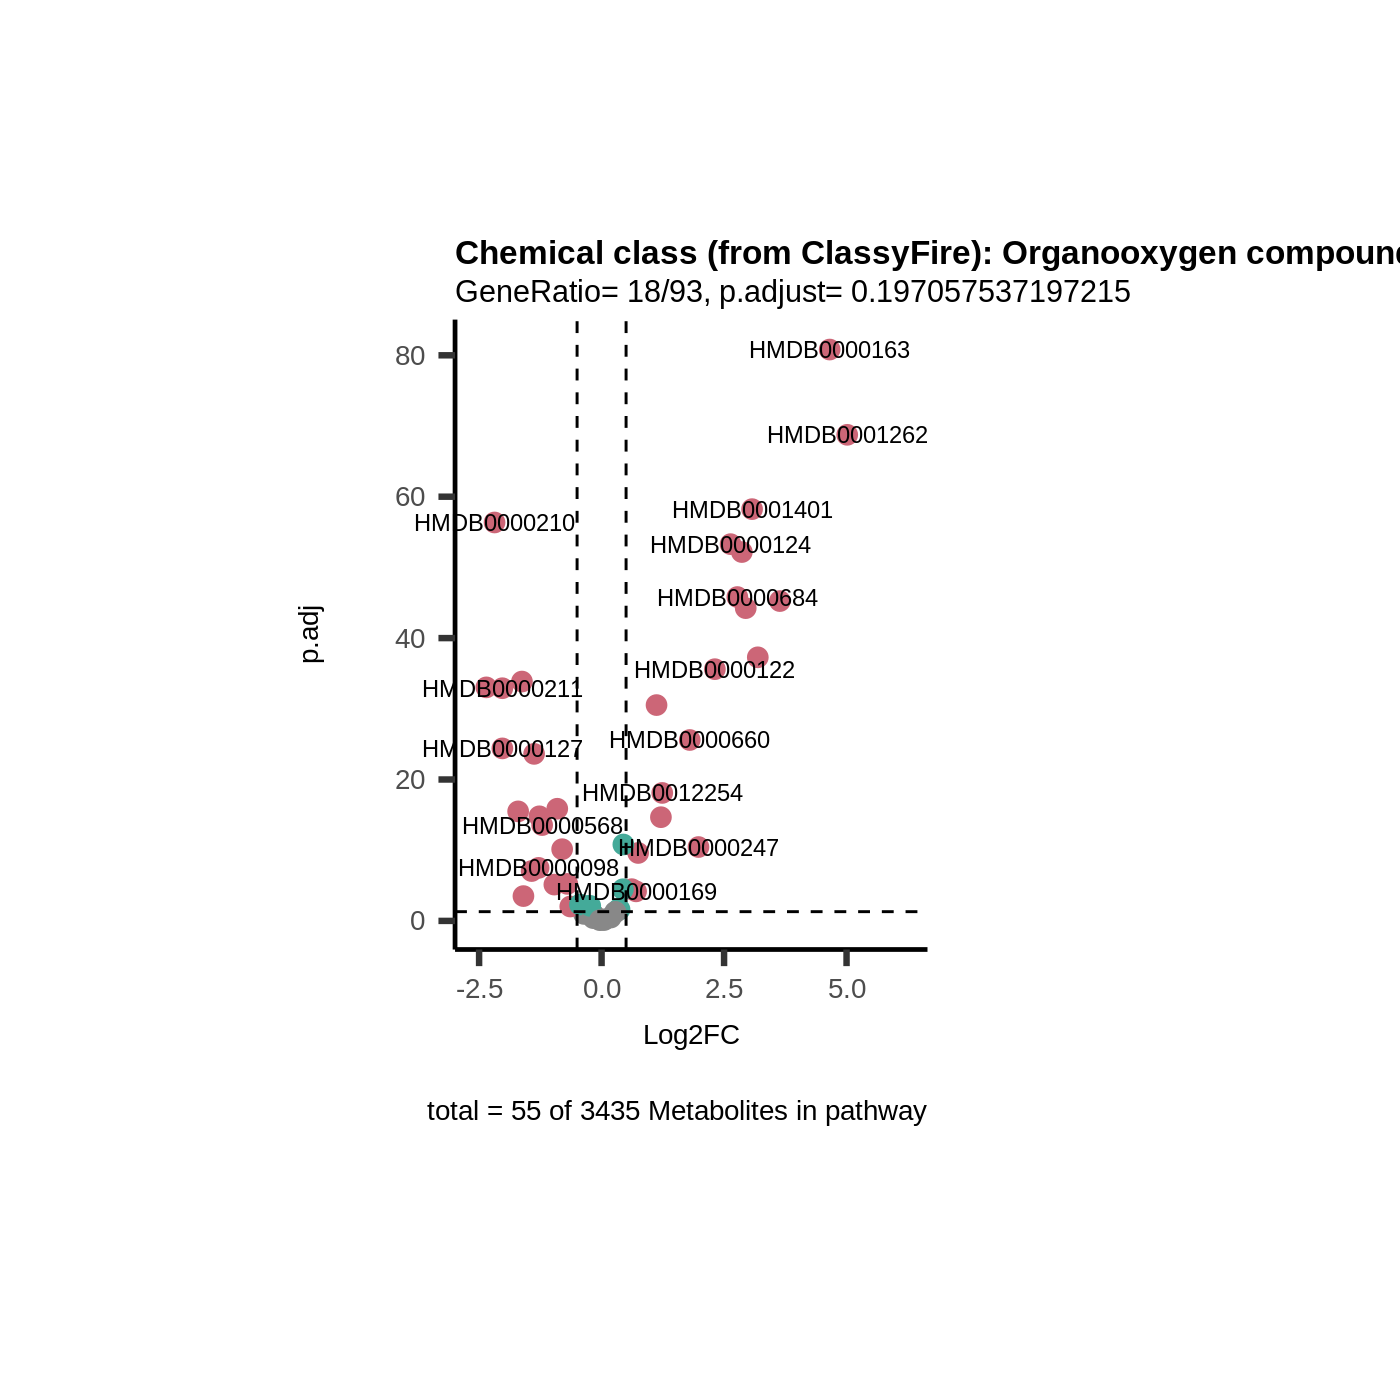

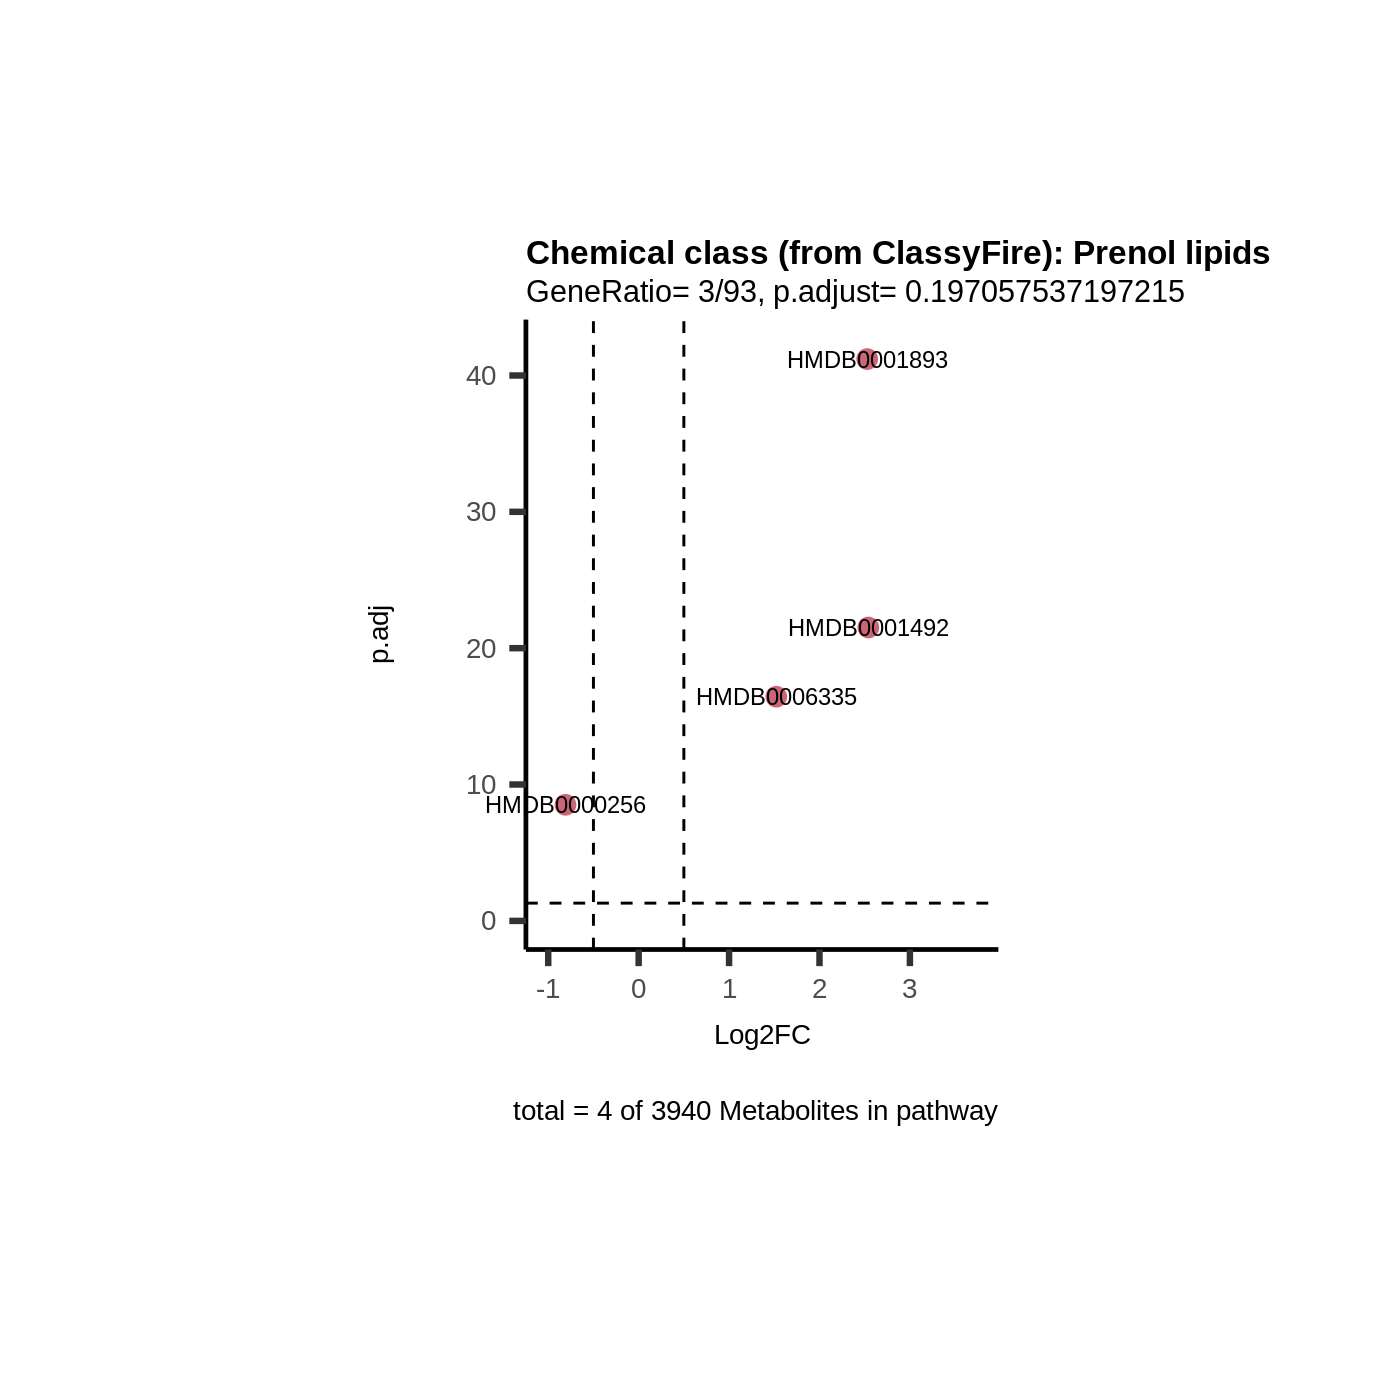

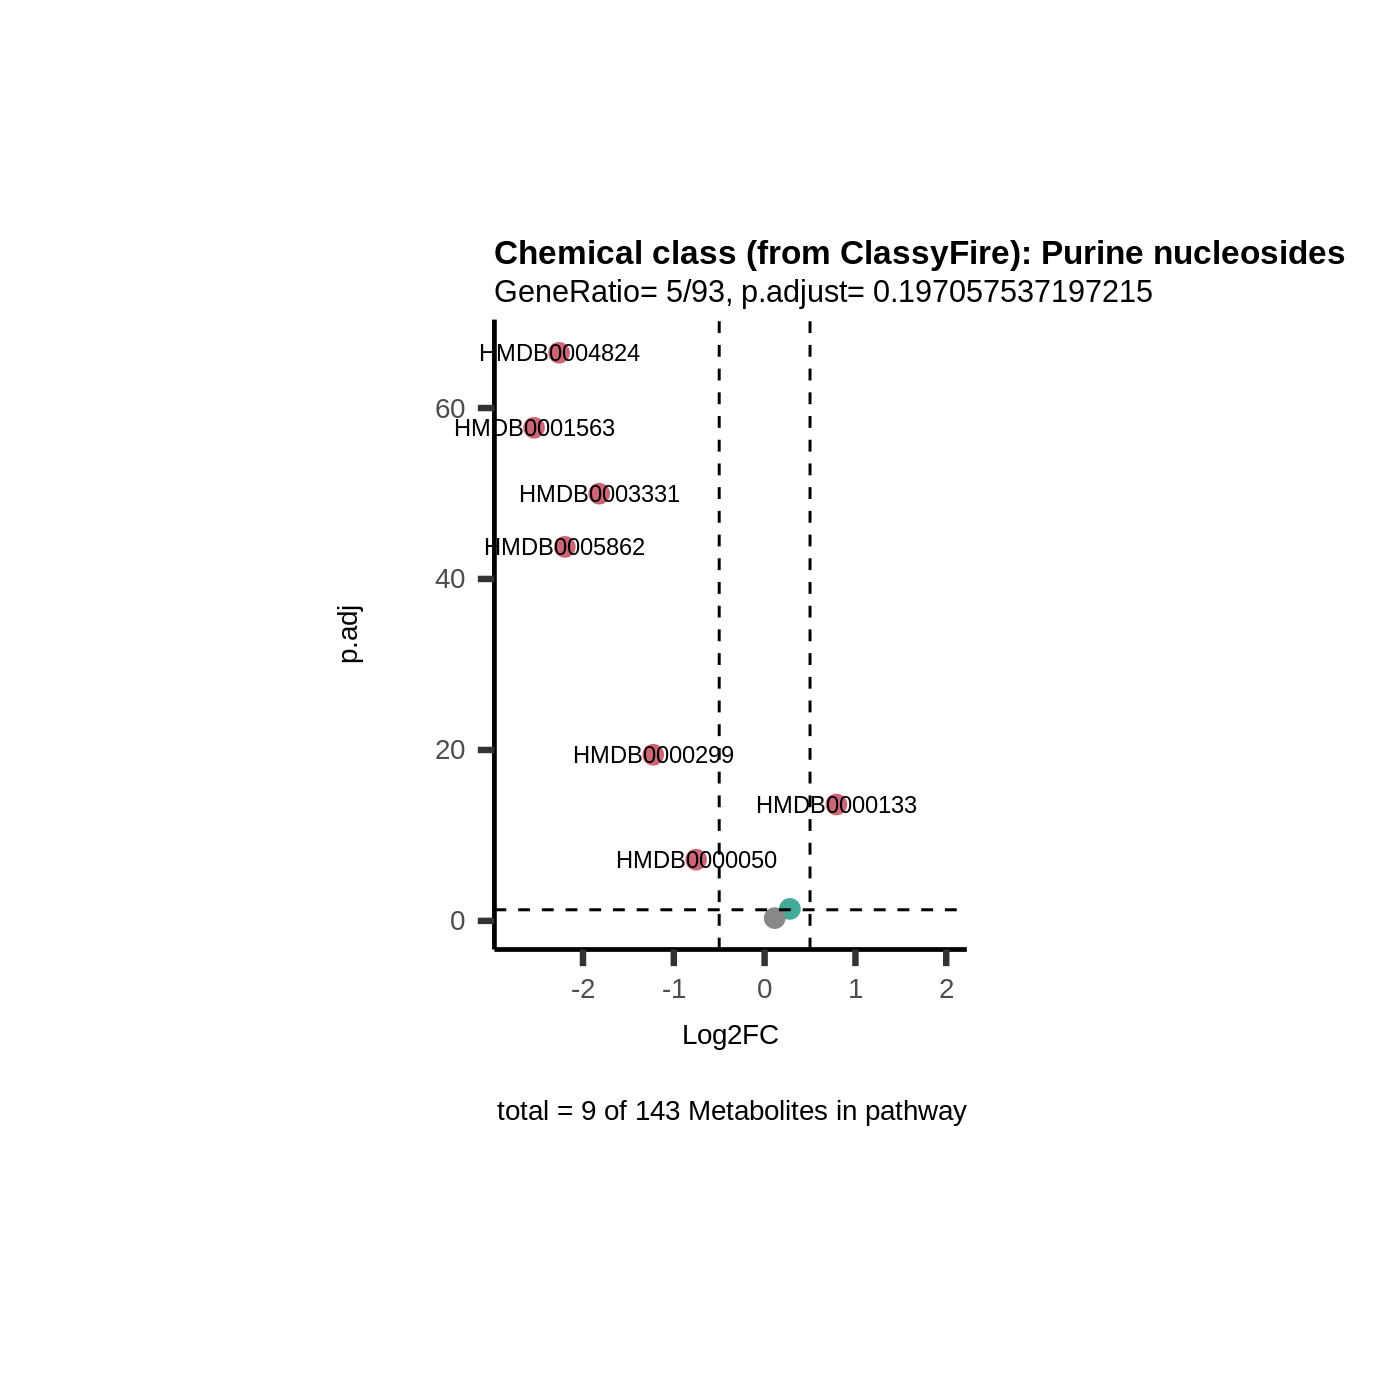

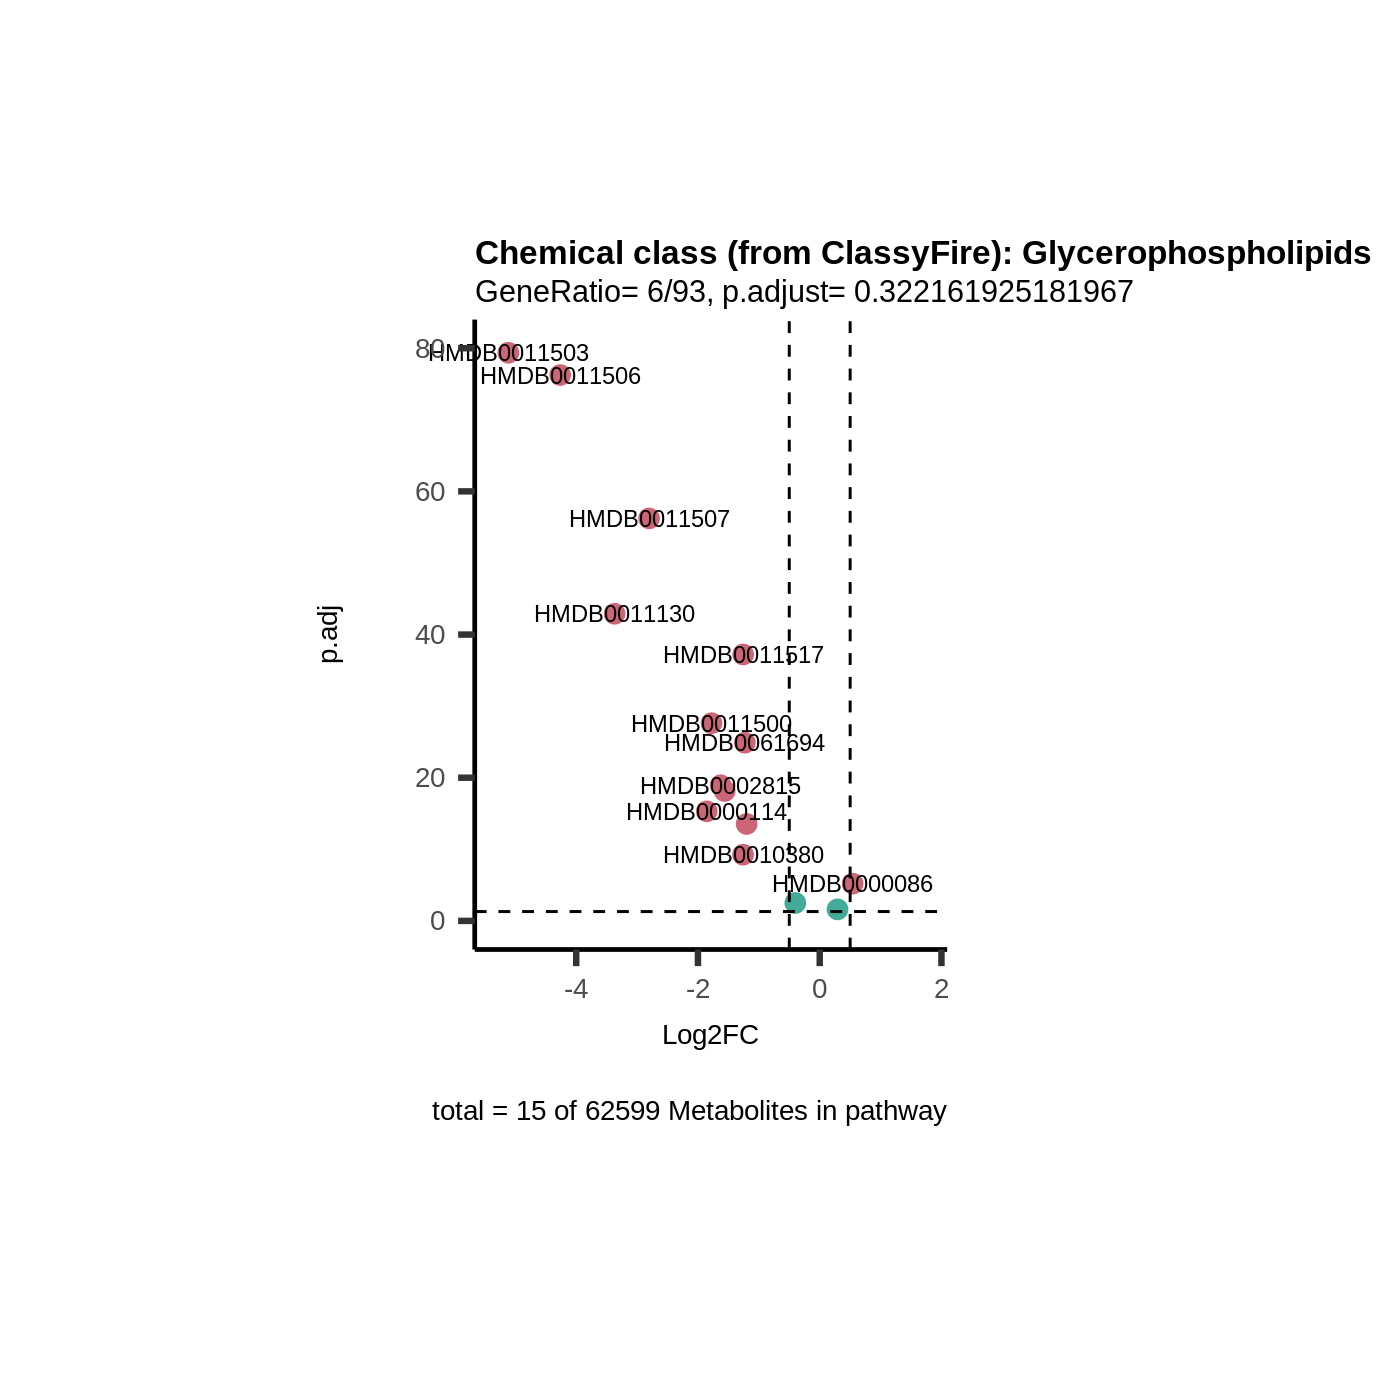

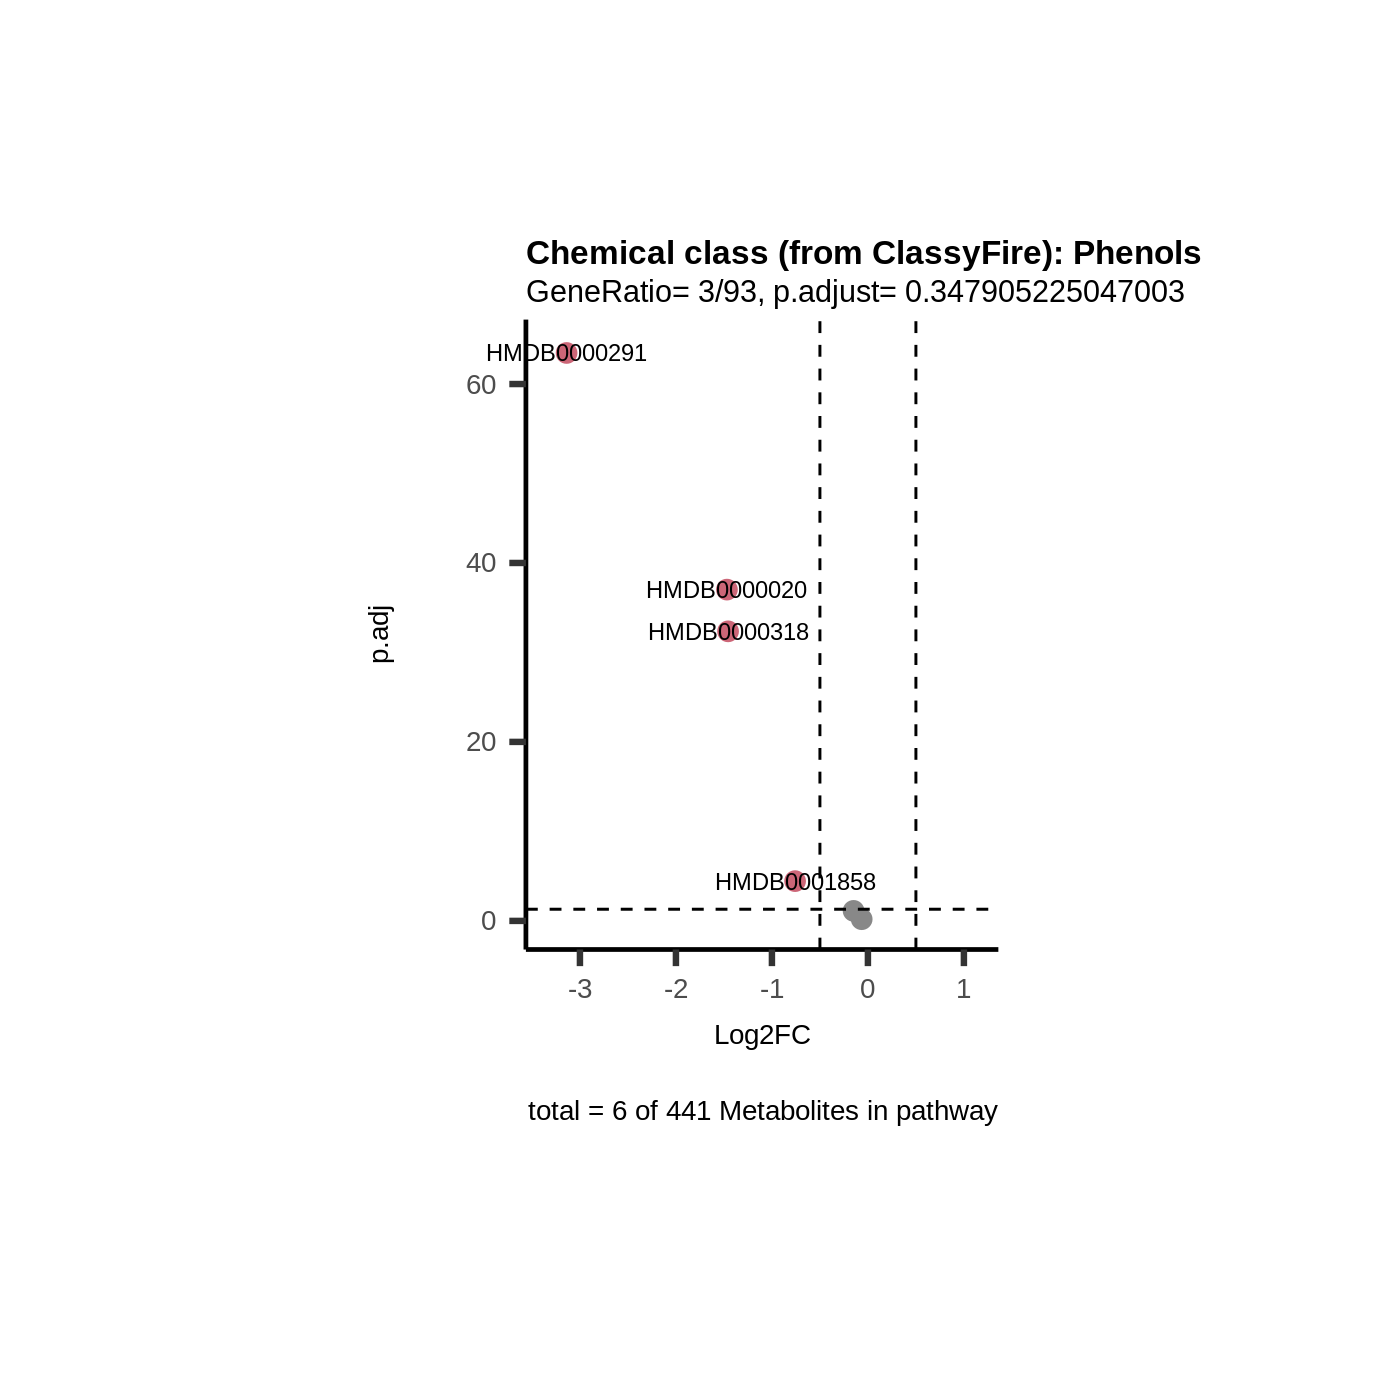

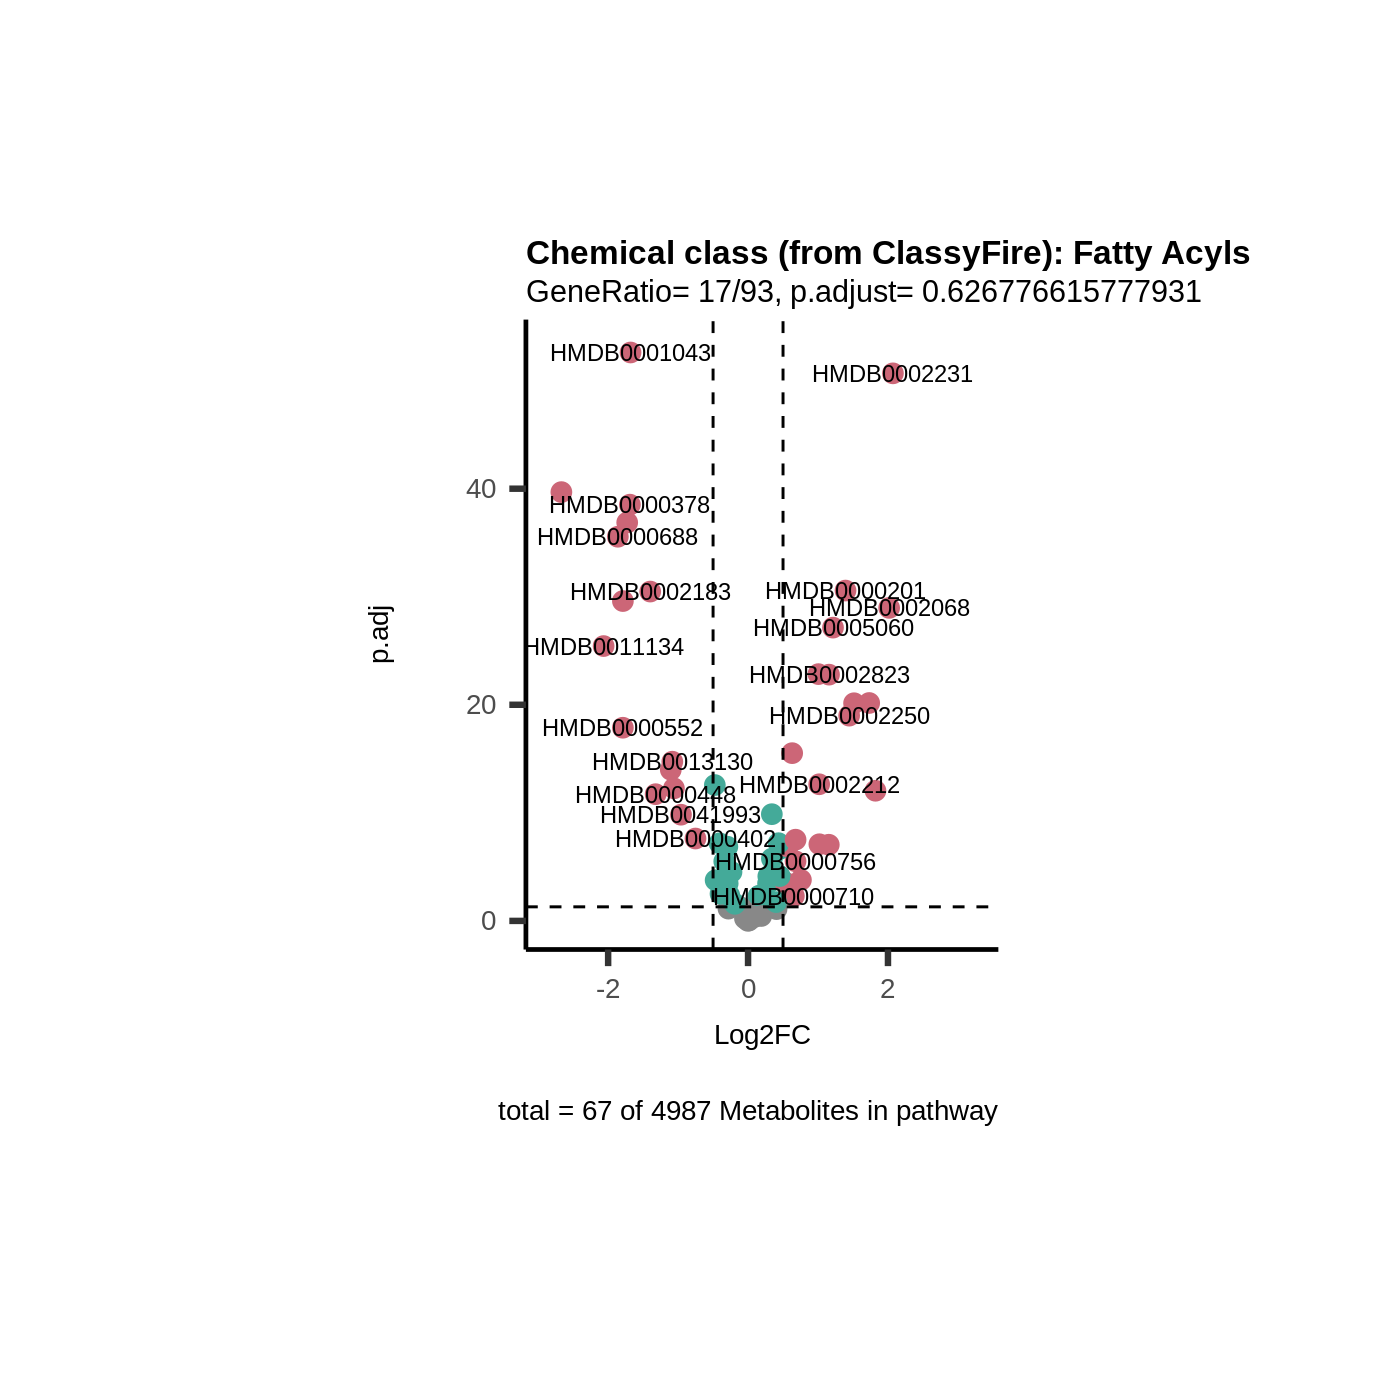

In [ ]:
# We only want to see the top pathways:
ora_top_pathways <-
  ORA_res$ClusterGosummary |>
  head()

# Volcano Plots
MetaProViz::viz_volcano(plot_types="PEA",
                       metadata_info= c(PEA_Pathway="ClassyFire_class",# Needs to be the same in both, metadata_feature and data2.
                                       PEA_stat="p.adjust",#Column data2
                                       PEA_score="GeneRatio",#Column data2
                                       PEA_Feature="class_source_id"),# Column metadata_feature (needs to be the same as row names in data)
                       metadata_feature= ChemicalClass,#Must be the pathways used for pathway analysis
                       data= tumour_vs_normal_for_ora, #Must be the data you have used as an input for the pathway analysis
                       data2= ora_top_pathways |> rename(ClassyFire_class = ID), #Must be the results of the pathway analysis
                       plot_name= "Chemical class (from ClassyFire)",
                       subtitle= "PEA" ,
                       select_label = NULL)

## Top features from the gender dementia study

Here we merge the top features from yesterday's *Identification* session with MetalinksDB, a resource of metabolite-protein interactions.

In [ ]:
gender_top_features_hmdb |>
  inner_join(MetalinksDB, by = c('hmdb' = 'hmdb')) |>
  select(hmdb, commonName, uniprot, gene_symbol, mode_of_regulation, protein_type) |>
  distinct()

hmdb,commonName,uniprot,gene_symbol,mode_of_regulation,protein_type
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
HMDB0000064,Creatine,P06732,CKM,Activating,NA
HMDB0000064,Creatine,P06732,CKM,Inhibiting,NA
HMDB0000064,Creatine,P12277,CKB,Activating,NA
HMDB0000064,Creatine,P12277,CKB,Inhibiting,NA
HMDB0000064,Creatine,P12532,CKMT1A,Activating,NA
HMDB0000064,Creatine,P12532,CKMT1A,Inhibiting,NA
HMDB0000064,Creatine,P17540,CKMT2,Activating,NA
HMDB0000064,Creatine,P17540,CKMT2,Inhibiting,NA
HMDB0000064,Creatine,P48029,SLC6A8,Activating,"""transporter"""


Creatine (higher in female):

*   A transporter (SLC6A8) transports it
*   We also see some enzymes acting on it
*   For example, GAMT is implicated in neurologic syndromes, [according to GeneCards](https://www.genecards.org/cgi-bin/carddisp.pl?gene=GAMT)

Octanoylcarnitine (higher in male):

*   3 transporters
*   Many enzymes

# Section 4: Biological interpretation
The biological interpretation of the functional analysis results is done in the context of the biological question and the experimental design. Here it is important to take into account:

1. What are the limitations of the PK used?
-  potential biases in the underlying original resources (e.g. if the PK is based on a specific database, it may not capture all relevant metabolites or pathways)
- choice of PK dictates the biological question that can be addressed

2. What is the coverage of your experimental data in the PK resource?
- As discussed in the section with the upset plots, if the PK only includes  HMDB IDs, this would exclude different classes of metabolites (primarily with LIMID ID)
- Certain pathways will not be covered by prior knowledge and hence can not be altered. Hence, the abscence amongst the significant hits is meaningless and it is important not to over-interpret the most altered pathways

3. Consider to combine multiple PK resources to increase the coverage of the detected metabolites or as done in the two example datasets assign classes to all features.

4. How many metabolites of e.g. a pathway in the PK have been detected?
- e.g. if a pathway only contains 25 metabolites and 16 of them are detected (64%), this is a stronger evidence than detecting 40 metabolites of a pathway containing 120 metabolites (33%)

5. What is the impact of metabolite set inflation and deflation on the results?
- Translating metabolite IDs from one identifier type to another, which can lead to one-to-none, one-to-one, one-to-many and many-to-many mappings between the metabolite ID types
- Mapping ambiguity can lead to inflation or deflation of the metabolite set size, which needs to be taken into account when interpreting the results

6. Which statistical method was used for enrichment analysis?
-  this impacts the interpretation of the results (see discussion above)


Lastly, ***metabolites are not genes*** and pathway analysis in metabolomics can produce misleading results due to the unique characteristics and constraints of metabolites compared to genes. For example, if a pathway is up-regulated in the context of genes, all the genes involved in that pathway produce more copies, whilst metabolite levels show lower coherence during regulation because the up-regulation can increase the abundance of the end-product but not necessarily of the metabolite intermediates. Consequently, it is important to always perform literature searches
for the top/bottom altered metabolite and be aware that beyond metabolic pathways, metabolites play an active role in gene-regulation by for example binding to receptors and elucidating signalling cascades. For a great perspective on this topic please check out this recent commentary in Nature Metabolism: https://www.nature.com/articles/s42255-025-01283-0


# Section 5: Mechanistic Modelling

Good resources to check:
- Cornetto: https://saezlab.github.io/corneto/dev/guide/metabolism/index.html
- CosmosR: https://saezlab.github.io/cosmosR/articles/tutorial.html#tutorial-section-signaling-to-metabolism

# Save and export the OmnipathR cache

To make the run more reliable in the training and to save time, we populate the cache directory (by default `~/.cache/OmnipathR`, this time `~/cache-ebi-metabo`) of OmnipathR in the beginning. This means all the prior knowledge access will work without performing actual downloads.

In [ ]:
'tar -czf {CACHE_TGZ} {CACHE_DIR} 2>&1' |> glue() |> system()